In [1]:
# Fig3: Dissecting the structural basis of burst and sustained dynamics through domain swapping
# Analysis to identify the three behavioral groups from the paper:
# 1. Slow-sustained: prolonged motion >12 h, velocity 10-50 nm/s
# 2. Fast-burst: brief motion < 2 h, velocity 50-1000 nm/s  
# 3. Multiphase: concentration-dependent transitions

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load and prepare data for behavioral classification
df = pd.read_csv('../../../Thomson Lab Dropbox/David Larios/activedrops/main/all/motor_dataset.csv')

# Keep essential columns for behavioral analysis (removed Translation Rate aa_s as it was faulty)
columns_to_keep = ['time (s)',  'Protein Concentration_nM', 'vorticity [1/s]_mean', 'divergence [1/s]_mean', 'velocity magnitude [m/s]_mean', 'shear [1/s]_mean', 'strain [1/s]_mean', 'correlation length [m]_mean', 'distance [m]_mean', 'power [W]_mean', 'work [J]_mean', 'protein', 'DNA nM']
df = df[columns_to_keep]

# Remove rows with missing protein names
df = df.dropna(subset=['protein'])

# Remove proteins that have only NaNs in velocity magnitude column
print("Before filtering:")
print(f"Total rows: {len(df)}")
print(f"Unique proteins: {df['protein'].nunique()}")

# Check which proteins have only NaN velocity measurements
velocity_nan_by_protein = df.groupby('protein')['velocity magnitude [m/s]_mean'].apply(lambda x: x.isna().all())
proteins_with_nan_velocity = velocity_nan_by_protein[velocity_nan_by_protein].index.tolist()

print(f"\nProteins with only NaN velocity measurements: {proteins_with_nan_velocity}")

# Remove these proteins
df = df[~df['protein'].isin(proteins_with_nan_velocity)]

print(f"\nAfter filtering:")
print(f"Total rows: {len(df)}")
print(f"Unique proteins: {df['protein'].nunique()}")
print(f"Remaining proteins: {df['protein'].unique()}")

# Create unique condition labels for each protein-DNA nM pair
df['condition_id'] = df['protein'].astype(str) + '-' + df['DNA nM'].astype(str) + 'nM'

# Check data quality
print(f"\nData quality check:")
print(f"Rows with valid velocity data: {df['velocity magnitude [m/s]_mean'].notna().sum()}")
print(f"Rows with valid time data: {df['time (s)'].notna().sum()}")
print(f"Rows with valid protein data: {df['protein'].notna().sum()}")

df

Before filtering:
Total rows: 177676
Unique proteins: 16

Proteins with only NaN velocity measurements: ['B', 'BleSto', 'E', 'F']

After filtering:
Total rows: 173452
Unique proteins: 12
Remaining proteins: ['A' 'H' 'C' 'G' 'D' 'ThTr' 'AcSu2' 'DiPu' 'HeAl' 'NaGr' 'AdPa' 'Kif5']

Data quality check:
Rows with valid velocity data: 119708
Rows with valid time data: 173452
Rows with valid protein data: 173452


,time (s),Protein Concentration_nM,vorticity [1/s]_mean,divergence [1/s]_mean,velocity magnitude [m/s]_mean,shear [1/s]_mean,strain [1/s]_mean,correlation length [m]_mean,distance [m]_mean,power [W]_mean,work [J]_mean,protein,DNA nM,condition_id
0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1.25,A-1.25nM
1,600.0,1.909813,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1.25,A-1.25nM
2,1200.0,3.075428,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1.25,A-1.25nM
3,1800.0,4.749361,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1.25,A-1.25nM
4,2400.0,6.528183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1.25,A-1.25nM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238316,131220.0,122.844224,7.554028e-08,6.000483e-07,6.008068e-10,1.705629e-07,-1.453127e-07,0.000112,0.000722,5.768031e-23,5.727192e-18,Kif5,160.00,Kif5-160.0nM
238317,131265.0,122.777871,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kif5,160.00,Kif5-160.0nM
238318,131310.0,122.759158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kif5,160.00,Kif5-160.0nM
238319,131355.0,122.815775,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kif5,160.00,Kif5-160.0nM


In [3]:
# Data quality analysis (self-contained)
print("\n" + "="*80)
print("DATA QUALITY ANALYSIS")
print("="*80)

# Define proteins and dna_concentrations locally for robustness
proteins = sorted([p for p in df['protein'].unique() if pd.notna(p)])
dna_concentrations = sorted([d for d in df['DNA nM'].unique() if pd.notna(d)])

# Analyze missing data patterns
print("Missing data patterns by protein:")
for protein in proteins:
    protein_data = df[df['protein'] == protein]
    total_rows = len(protein_data)
    if total_rows == 0:
        continue
    valid_velocity = protein_data['velocity magnitude [m/s]_mean'].notna().sum()
    valid_time = protein_data['time (s)'].notna().sum()
    valid_both = protein_data.dropna(subset=['time (s)', 'velocity magnitude [m/s]_mean']).shape[0]
    
    print(f"  {protein:8s}: {total_rows:6d} total rows, {valid_velocity:6d} valid velocity ({(valid_velocity/total_rows*100):5.1f}%), {valid_both:6d} valid both ({(valid_both/total_rows*100):5.1f}%)")

print(f"\nMissing data patterns by DNA concentration:")
for dna_conc in dna_concentrations:
    conc_data = df[df['DNA nM'] == dna_conc]
    total_rows = len(conc_data)
    if total_rows == 0:
        continue
    valid_velocity = conc_data['velocity magnitude [m/s]_mean'].notna().sum()
    valid_both = conc_data.dropna(subset=['time (s)', 'velocity magnitude [m/s]_mean']).shape[0]
    
    print(f"  {dna_conc:8.1f} nM: {total_rows:6d} total rows, {valid_velocity:6d} valid velocity ({(valid_velocity/total_rows*100):5.1f}%), {valid_both:6d} valid both ({(valid_both/total_rows*100):5.1f}%)")

# Check for complete protein-DNA combinations
print(f"\nComplete protein-DNA combinations (with valid velocity data):")
complete_combinations = 0
for protein in proteins:
    for dna_conc in dna_concentrations:
        combo_data = df[(df['protein'] == protein) & (df['DNA nM'] == dna_conc)]
        if not combo_data.empty:
            valid_data = combo_data.dropna(subset=['time (s)', 'velocity magnitude [m/s]_mean'])
            if not valid_data.empty:
                complete_combinations += 1
                print(f"  {protein} - {dna_conc} nM: {len(valid_data)} valid points")

print(f"\nTotal complete combinations: {complete_combinations}")
print(f"Total possible combinations: {len(proteins) * len(dna_concentrations)}")
print(f"Completion rate: {complete_combinations / (len(proteins) * len(dna_concentrations)) * 100:.1f}%")



DATA QUALITY ANALYSIS
Missing data patterns by protein:
  A       :   4130 total rows,   2960 valid velocity ( 71.7%),   2960 valid both ( 71.7%)
  AcSu2   :   7112 total rows,   7030 valid velocity ( 98.8%),   7030 valid both ( 98.8%)
  AdPa    :  29816 total rows,   1752 valid velocity (  5.9%),   1752 valid both (  5.9%)
  C       :   9466 total rows,   9466 valid velocity (100.0%),   9466 valid both (100.0%)
  D       :   5277 total rows,   5277 valid velocity (100.0%),   5277 valid both (100.0%)
  DiPu    :   1320 total rows,    990 valid velocity ( 75.0%),    990 valid both ( 75.0%)
  G       :  11872 total rows,  11872 valid velocity (100.0%),  11872 valid both (100.0%)
  H       :   4230 total rows,   4230 valid velocity (100.0%),   4230 valid both (100.0%)
  HeAl    :   7048 total rows,   7048 valid velocity (100.0%),   7048 valid both (100.0%)
  Kif5    :   2921 total rows,    973 valid velocity ( 33.3%),    973 valid both ( 33.3%)
  NaGr    :  30840 total rows,   8832 valid

Dataset shape: (173452, 14)

Column names:
['time (s)', 'Protein Concentration_nM', 'vorticity [1/s]_mean', 'divergence [1/s]_mean', 'velocity magnitude [m/s]_mean', 'shear [1/s]_mean', 'strain [1/s]_mean', 'correlation length [m]_mean', 'distance [m]_mean', 'power [W]_mean', 'work [J]_mean', 'protein', 'DNA nM', 'condition_id']

Data types:
time (s)                         float64
Protein Concentration_nM         float64
vorticity [1/s]_mean             float64
divergence [1/s]_mean            float64
velocity magnitude [m/s]_mean    float64
shear [1/s]_mean                 float64
strain [1/s]_mean                float64
correlation length [m]_mean      float64
distance [m]_mean                float64
power [W]_mean                   float64
work [J]_mean                    float64
protein                           object
DNA nM                           float64
condition_id                      object
dtype: object

Missing values:
time (s)                             0
Protein Conc

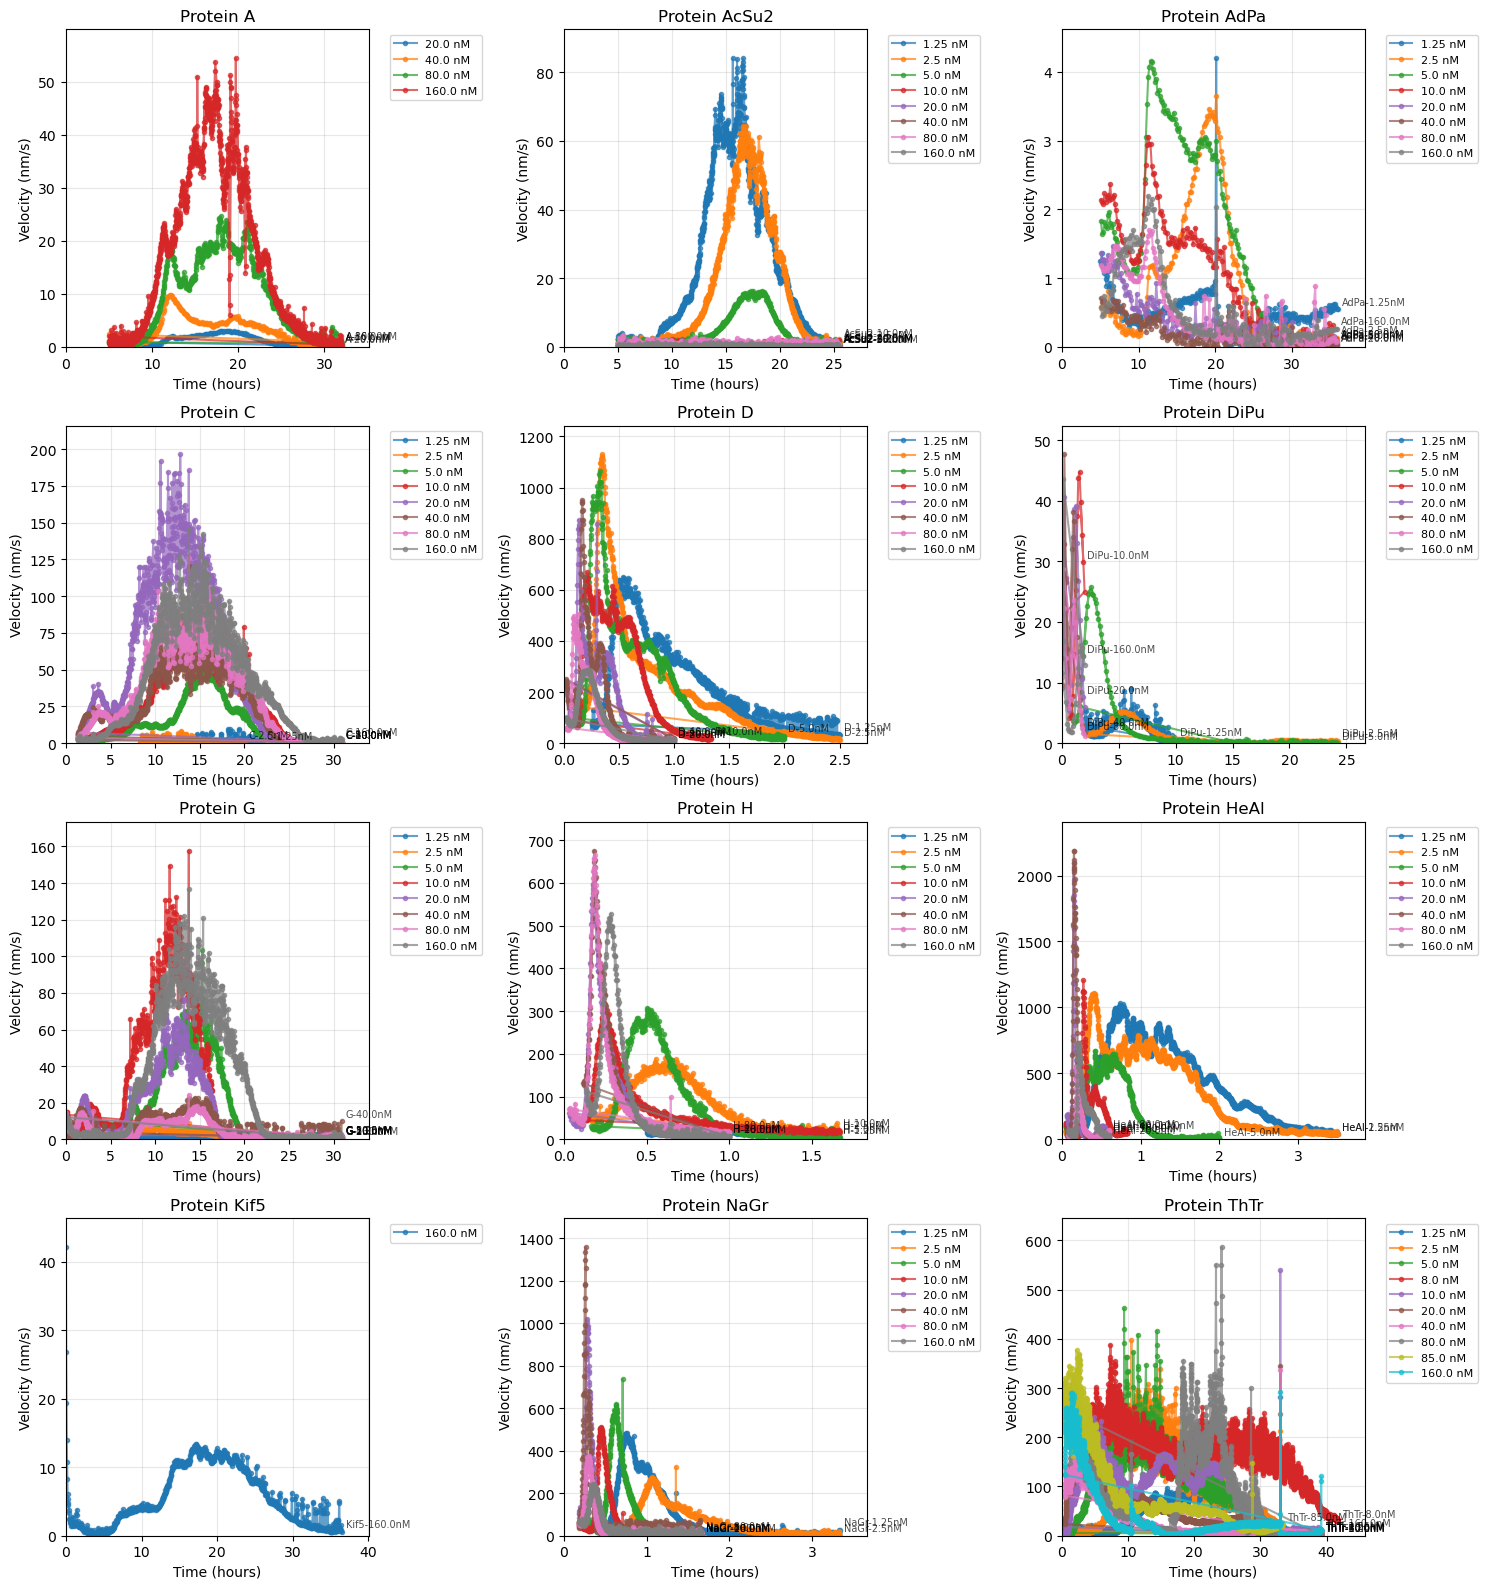


Plotting complete for 12 proteins


In [4]:
# First, let's examine the data structure and prepare for analysis
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

# Create velocity vs time plots for each protein across different DNA concentrations
print("\n" + "="*80)
print("VELOCITY vs TIME PLOTS FOR EACH PROTEIN")
print("="*80)

# Get unique proteins and DNA concentrations (remove NaN values)
proteins = sorted([p for p in df['protein'].unique() if pd.notna(p)])
dna_concentrations = sorted([d for d in df['DNA nM'].unique() if pd.notna(d)])

print(f"Proteins: {proteins}")
print(f"DNA concentrations: {dna_concentrations}")

# Create subplots for each protein
n_proteins = len(proteins)
n_cols = 3
n_rows = (n_proteins + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_proteins == 1:
    axes = [axes]
axes = axes.flatten()

for i, protein in enumerate(proteins):
    ax = axes[i]
    
    # Get data for this protein
    protein_data = df[df['protein'] == protein]
    print(f"\nProcessing protein {protein}: {len(protein_data)} rows")
    
    # Plot each DNA concentration as a separate line
    plotted_any = False
    for dna_conc in dna_concentrations:
        conc_data = protein_data[protein_data['DNA nM'] == dna_conc]
        if not conc_data.empty:
            # Convert time to hours and velocity to nm/s
            time_hours = conc_data['time (s)'] / 3600
            velocity_nm_s = conc_data['velocity magnitude [m/s]_mean'] * 1e9
            
            # Only plot if we have valid data
            valid_mask = ~velocity_nm_s.isna() & ~time_hours.isna()
            if valid_mask.any():
                ax.plot(time_hours[valid_mask], velocity_nm_s[valid_mask], 
                       marker='o', markersize=3, alpha=0.7, 
                       label=f'{dna_conc} nM', linewidth=1.5)
                plotted_any = True
                print(f"  DNA {dna_conc} nM: {valid_mask.sum()} valid points")
    
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Velocity (nm/s)')
    ax.set_title(f'Protein {protein}')
    
    # Annotate the last point of each series with condition label for clarity
    for dna_conc in dna_concentrations:
        conc_data = protein_data[protein_data['DNA nM'] == dna_conc]
        if not conc_data.empty:
            valid = conc_data.dropna(subset=['time (s)', 'velocity magnitude [m/s]_mean'])
            if not valid.empty:
                last = valid.iloc[-1]
                ax.annotate(
                    f"{protein}-{dna_conc}nM",
                    (last['time (s)']/3600, last['velocity magnitude [m/s]_mean']*1e9),
                    xytext=(3,3), textcoords='offset points', fontsize=7, alpha=0.7
                )
    ax.grid(True, alpha=0.3)
    
    if plotted_any:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        
        # Set reasonable axis limits
        if not protein_data.empty:
            valid_data = protein_data.dropna(subset=['time (s)', 'velocity magnitude [m/s]_mean'])
            if not valid_data.empty:
                max_time = valid_data['time (s)'].max() / 3600
                max_vel = valid_data['velocity magnitude [m/s]_mean'].max() * 1e9
                if not np.isnan(max_time) and not np.isnan(max_vel):
                    ax.set_xlim(0, max_time * 1.1)
                    ax.set_ylim(0, max_vel * 1.1)
    else:
        ax.text(0.5, 0.5, 'No valid data', transform=ax.transAxes, 
                ha='center', va='center', fontsize=12, alpha=0.5)

# Hide unused subplots
for i in range(n_proteins, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nPlotting complete for {n_proteins} proteins")


In [5]:
# Prepare data for clustering analysis
# We want to classify PROTEINS, not individual concentration conditions
# So we'll aggregate across all concentrations for each protein

print("Approach: Classify proteins based on their behavior across all concentrations")
print("=" * 70)

# Group by protein only to get summary statistics across all concentrations
df_protein_summary = df.groupby('protein').agg({
    'time (s)': ['max', 'mean', 'std'],  # Duration statistics
    'velocity magnitude [m/s]_mean': ['mean', 'max', 'std', 'min'],
    'power [W]_mean': ['mean', 'max', 'std'],
    'vorticity [1/s]_mean': ['mean', 'std'],
    'shear [1/s]_mean': ['mean', 'std'],
    'strain [1/s]_mean': ['mean', 'std'],
    'correlation length [m]_mean': ['mean', 'std'],
    'distance [m]_mean': ['mean', 'std'],
    'work [J]_mean': ['mean', 'max', 'std'],
    'Protein Concentration_nM': ['mean', 'max', 'std'],
    'DNA nM': ['nunique']  # Number of different DNA concentrations tested
}).reset_index()

# Flatten column names
df_protein_summary.columns = ['_'.join(col).strip() for col in df_protein_summary.columns.values]
df_protein_summary.columns = df_protein_summary.columns.str.replace('_<lambda_0>', '')

# Fix the protein column name
df_protein_summary = df_protein_summary.rename(columns={'protein_': 'protein'})

print("Protein-level summary dataset shape:", df_protein_summary.shape)
print("\nProteins analyzed:")
print(df_protein_summary['condition_id'].tolist())
print("\nSummary columns:")
print(df_protein_summary.columns.tolist())
df_protein_summary.head()


Approach: Classify proteins based on their behavior across all concentrations
Protein-level summary dataset shape: (12, 28)

Proteins analyzed:


KeyError: 'condition_id'

In [6]:
# Compute translation rate (d[Protein]_nM/dt) per (protein, DNA) and add to df
print("\n" + "="*80)
print("COMPUTE TRANSLATION RATE AND PEAK TIMING")
print("="*80)

from scipy.stats import linregress

# Initialize new columns
df['translation rate [nM/s]'] = np.nan

# Per-condition summaries to capture relationships vs DNA
per_condition_records = []

for condition_id, g in df.dropna(subset=['condition_id']).groupby('condition_id', dropna=False):
    g_sorted = g.sort_values('time (s)').copy()
    t = g_sorted['time (s)'].values
    pc = g_sorted['Protein Concentration_nM'].values
    v = g_sorted['velocity magnitude [m/s]_mean'].values
    pwr = g_sorted['power [W]_mean'].values

    # Compute translation rate via gradient (handle missing)
    valid = ~np.isnan(t) & ~np.isnan(pc)
    tr = np.full_like(pc, np.nan, dtype=float)
    if np.sum(valid) >= 2 and np.all(np.diff(t[valid]) > 0):
        tr_valid = np.gradient(pc[valid], t[valid])
        tr[valid] = tr_valid

    # Assign back into df
    df.loc[g_sorted.index, 'translation rate [nM/s]'] = tr

    # Condition summaries
    max_vel = np.nanmax(v) if v.size else np.nan
    max_pwr = np.nanmax(pwr) if pwr.size else np.nan
    # Approximate energy as integral of power over time (J)
    energy_j = np.nan
    if np.sum(~np.isnan(pwr) & ~np.isnan(t)) >= 2:
        tv = t[~np.isnan(pwr) & ~np.isnan(t)]
        pv = pwr[~np.isnan(pwr) & ~np.isnan(t)]
        if np.all(np.diff(tv) > 0):
            energy_j = float(np.trapz(pv, tv))

    # Translation rate peaks
    max_tr = np.nanmax(tr) if np.any(~np.isnan(tr)) else np.nan
    time_to_peak_tr_h = np.nan
    if np.any(~np.isnan(tr)):
        idx = np.nanargmax(tr)
        if not np.isnan(t[idx]):
            time_to_peak_tr_h = t[idx] / 3600.0

    per_condition_records.append({
        'condition_id': condition_id,
        'max_velocity_m_per_s': max_vel,
        'max_power_W': max_pwr,
        'energy_J': energy_j,
        'max_translation_rate_nM_per_s': max_tr,
        'time_to_peak_translation_rate_hours': time_to_peak_tr_h,
    })

per_condition_df = pd.DataFrame(per_condition_records)
print("Per-condition summary head:")
print(per_condition_df.head())

# Translation rate features are already per condition, no need to aggregate
# per_condition_df already has the right structure

# DNA concentration dependence analysis is not needed for condition-level analysis
# Each condition is already a unique sample
print("\nCondition-level analysis complete - no DNA concentration dependence needed.")



COMPUTE TRANSLATION RATE AND PEAK TIMING
Per-condition summary head:
  condition_id  max_velocity_m_per_s   max_power_W      energy_J  \
0     A-1.25nM                   NaN           NaN           NaN   
1     A-10.0nM                   NaN           NaN           NaN   
2    A-160.0nM          5.441118e-08  2.505042e-19  2.987145e-15   
3      A-2.5nM                   NaN           NaN           NaN   
4     A-20.0nM          3.098720e-09  1.418586e-22  3.317521e-18   

   max_translation_rate_nM_per_s  time_to_peak_translation_rate_hours  
0                       0.011435                            29.833333  
1                       0.013867                            27.333333  
2                       0.024426                            26.500000  
3                       0.012155                            27.333333  
4                       0.018273                            19.666667  

Condition-level analysis complete - no DNA concentration dependence needed.


In [7]:
# CONDITION-LEVEL SUMMARY (each (protein, DNA nM) is one sample)
print("\n" + "="*80)
print("CONDITION-LEVEL SUMMARY (protein, DNA nM as samples)")
print("="*80)

# Use condition_id as the grouping key instead of protein
df['sample_id'] = df['condition_id']

# Local helpers (self-contained)
def _duration_above_threshold_seconds(group: pd.DataFrame) -> float:
    g = group.sort_values('time (s)')
    v = g['velocity magnitude [m/s]_mean']
    t = g['time (s)']
    if v.dropna().empty or t.dropna().empty:
        return 0.0
    vmax = v.max()
    if pd.isna(vmax) or vmax <= 0:
        return 0.0
    thr = 0.2 * vmax
    valid = (v >= thr) & t.notna() & v.notna()
    if valid.sum() < 2:
        return 0.0
    tv = t[valid].values
    dt = np.diff(tv)
    dt = dt[dt > 0]
    return float(np.sum(dt)) if len(dt) else 0.0

def _activation_onset_seconds(group: pd.DataFrame) -> float:
    g = group.sort_values('time (s)')
    v = g['velocity magnitude [m/s]_mean']
    t = g['time (s)']
    if v.dropna().empty or t.dropna().empty:
        return np.nan
    vmax = v.max()
    if pd.isna(vmax) or vmax <= 0:
        return np.nan
    thr = 0.2 * vmax
    valid = (v >= thr) & t.notna() & v.notna()
    if not valid.any():
        return np.nan
    return float(t[valid].iloc[0])

# Aggregate core stats per condition_id (unique protein-DNA nM pairs)
df_condition_summary = df.groupby('condition_id').agg({
    'time (s)': ['max', 'count'],
    'velocity magnitude [m/s]_mean': ['mean', 'max', 'std', 'min'],
    'power [W]_mean': ['mean', 'max', 'std'],
    'vorticity [1/s]_mean': ['mean', 'std'],
    'shear [1/s]_mean': ['mean', 'std'],
    'strain [1/s]_mean': ['mean', 'std'],
    'correlation length [m]_mean': ['mean', 'std'],
    'distance [m]_mean': ['mean', 'std'],
    'work [J]_mean': ['mean', 'max', 'std'],
    'Protein Concentration_nM': ['mean', 'max', 'std'],
})

# Flatten and restore keys
df_condition_summary.columns = ['_'.join(col).strip() for col in df_condition_summary.columns.values]
df_condition_summary.columns = df_condition_summary.columns.str.replace('_<lambda_0>', '')
df_condition_summary = df_condition_summary.reset_index()  # This makes condition_id a column

# Duration ≥20% vmax per condition
cond_durations = (
    df.dropna(subset=['condition_id'])
      .groupby('condition_id', dropna=False)
      .apply(_duration_above_threshold_seconds)
      .reset_index(name='duration_high_velocity_s')
)
cond_durations['duration_high_velocity_hours'] = cond_durations['duration_high_velocity_s'] / 3600.0
# condition_id is now a column after reset_index()

# Activation onset per condition
cond_onset = (
    df.dropna(subset=['condition_id'])
      .groupby('condition_id', dropna=False)
      .apply(_activation_onset_seconds)
      .reset_index(name='activation_onset_s')
)
cond_onset['activation_onset_hours'] = cond_onset['activation_onset_s'] / 3600.0
# condition_id is now a column after reset_index()

# Ensure per_condition_df exists; compute if missing
try:
    _ = per_condition_df
except NameError:
    per_condition_records = []
    for condition_id, g in df.dropna(subset=['condition_id']).groupby('condition_id', dropna=False):
        gs = g.sort_values('time (s)')
        t = gs['time (s)'].values
        pc = gs['Protein Concentration_nM'].values
        v = gs['velocity magnitude [m/s]_mean'].values
        pwr = gs['power [W]_mean'].values
        tr = np.full_like(pc, np.nan, dtype=float)
        valid = ~np.isnan(t) & ~np.isnan(pc)
        if np.sum(valid) >= 2 and np.all(np.diff(t[valid]) > 0):
            tr[valid] = np.gradient(pc[valid], t[valid])
        max_tr = np.nanmax(tr) if np.any(~np.isnan(tr)) else np.nan
        t_peak_tr_h = np.nan
        if np.any(~np.isnan(tr)):
            idx = np.nanargmax(tr)
            if not np.isnan(t[idx]):
                t_peak_tr_h = t[idx] / 3600.0
        max_vel = np.nanmax(v) if v.size else np.nan
        max_pwr = np.nanmax(pwr) if pwr.size else np.nan
        energy_j = np.nan
        if np.sum(~np.isnan(pwr) & ~np.isnan(t)) >= 2:
            tv = t[~np.isnan(pwr) & ~np.isnan(t)]
            pv = pwr[~np.isnan(pwr) & ~np.isnan(t)]
            if np.all(np.diff(tv) > 0):
                energy_j = float(np.trapz(pv, tv))
        per_condition_records.append({
            'condition_id': condition_id,
            'max_velocity_m_per_s': max_vel,
            'max_power_W': max_pwr,
            'energy_J': energy_j,
            'max_translation_rate_nM_per_s': max_tr,
            'time_to_peak_translation_rate_hours': t_peak_tr_h,
        })
    per_condition_df = pd.DataFrame(per_condition_records)

# Compute correlation length and time at max velocity per condition
vmax_metrics = (
    df.dropna(subset=['condition_id'])
      .groupby('condition_id', dropna=False)
      .apply(lambda g: (
          pd.Series({
              'correlation_length_at_vmax_m': (
                  g.loc[g['velocity magnitude [m/s]_mean'].idxmax(), 'correlation length [m]_mean']
                  if g['velocity magnitude [m/s]_mean'].notna().any() else np.nan
              ),
              'time_to_max_velocity_hours': (
                  g.loc[g['velocity magnitude [m/s]_mean'].idxmax(), 'time (s)']/3600.0
                  if g['velocity magnitude [m/s]_mean'].notna().any() else np.nan
              )
          })
      ))
      .reset_index()
)
# condition_id is now a column after reset_index()

# Compute smoothed vorticity/divergence per condition and take MEAN (sigma=10)
def _smooth_mean(group: pd.DataFrame) -> pd.Series:
    gs = group.sort_values('time (s)')
    out = {
        'vorticity_mean_smoothed': np.nan,
        'divergence_mean_smoothed': np.nan,
    }
    # Vorticity
    v = gs['vorticity [1/s]_mean'].values
    if np.any(~np.isnan(v)):
        v_fill = pd.Series(v).interpolate(limit_direction='both').to_numpy()
        v_s = gaussian_filter1d(v_fill, sigma=10)
        out['vorticity_mean_smoothed'] = float(np.nanmean(v_s))
    # Divergence
    d = gs['divergence [1/s]_mean'].values if 'divergence [1/s]_mean' in gs.columns else None
    if d is not None and np.any(~np.isnan(d)):
        d_fill = pd.Series(d).interpolate(limit_direction='both').to_numpy()
        d_s = gaussian_filter1d(d_fill, sigma=10)
        out['divergence_mean_smoothed'] = float(np.nanmean(d_s))
    return pd.Series(out)

smooth_stats = (
    df.dropna(subset=['condition_id'])
      .groupby('condition_id', dropna=False)
      .apply(_smooth_mean)
      .reset_index()
)
# condition_id is now a column after reset_index()

# Debug: Check what columns each dataframe has
print("df_condition_summary columns:", df_condition_summary.columns.tolist())
print("per_condition_df columns:", per_condition_df.columns.tolist())
print("cond_durations columns:", cond_durations.columns.tolist())
print("cond_onset columns:", cond_onset.columns.tolist())
print("vmax_metrics columns:", vmax_metrics.columns.tolist())
print("smooth_stats columns:", smooth_stats.columns.tolist())

# Merge all condition-level features
df_condition_summary = (df_condition_summary
    .merge(per_condition_df, on='condition_id', how='left')
    .merge(cond_durations[['condition_id', 'duration_high_velocity_hours']], on='condition_id', how='left')
    .merge(cond_onset[['condition_id', 'activation_onset_hours']], on='condition_id', how='left')
    .merge(vmax_metrics, on='condition_id', how='left')
    .merge(smooth_stats, on='condition_id', how='left')
)

# Use condition-level summary for downstream analysis
df_protein_summary = df_condition_summary.copy()
print("Samples (conditions):", len(df_protein_summary))
print("Columns:")
print(df_protein_summary.columns.tolist())
print("Sample IDs:", df_protein_summary['condition_id'].tolist())



CONDITION-LEVEL SUMMARY (protein, DNA nM as samples)
df_condition_summary columns: ['condition_id', 'time (s)_max', 'time (s)_count', 'velocity magnitude [m/s]_mean_mean', 'velocity magnitude [m/s]_mean_max', 'velocity magnitude [m/s]_mean_std', 'velocity magnitude [m/s]_mean_min', 'power [W]_mean_mean', 'power [W]_mean_max', 'power [W]_mean_std', 'vorticity [1/s]_mean_mean', 'vorticity [1/s]_mean_std', 'shear [1/s]_mean_mean', 'shear [1/s]_mean_std', 'strain [1/s]_mean_mean', 'strain [1/s]_mean_std', 'correlation length [m]_mean_mean', 'correlation length [m]_mean_std', 'distance [m]_mean_mean', 'distance [m]_mean_std', 'work [J]_mean_mean', 'work [J]_mean_max', 'work [J]_mean_std', 'Protein Concentration_nM_mean', 'Protein Concentration_nM_max', 'Protein Concentration_nM_std']
per_condition_df columns: ['condition_id', 'max_velocity_m_per_s', 'max_power_W', 'energy_J', 'max_translation_rate_nM_per_s', 'time_to_peak_translation_rate_hours']
cond_durations columns: ['condition_id', 'd

In [8]:
# NOTE: This cell is deprecated in condition-level analysis and intentionally left empty.
# Duration >=20% vmax per condition is already computed in the condition-level summary (df_protein_summary).



In [9]:
# Select features for clustering analysis
# Focus on the key metrics that define the behavioral groups

# First, let's see what columns are actually available
print("Available columns in df_protein_summary:")
print(df_protein_summary.columns.tolist())
print(f"Shape: {df_protein_summary.shape}")
print(f"Sample IDs: {df_protein_summary['condition_id'].tolist()}")
print()

# Select features that capture protein behavior across all concentrations
# Drop power (derived) to avoid redundancy; include divergence; keep duration metric
features = [
    
    'velocity magnitude [m/s]_mean_max',    # Peak velocity across concentrations
    
    'vorticity_mean_smoothed',              # Smoothed vorticity mean
    'shear [1/s]_mean_mean',                # Average shear
    'strain [1/s]_mean_mean',               # Average strain
    'divergence_mean_smoothed',             # Smoothed divergence mean
    'correlation_length_at_vmax_m',        # Correlation length at max velocity
    
    'work [J]_mean_max',                    # Peak work across time
    'time_to_max_velocity_hours',           # Time at max velocity
    'activation_onset_hours',               # Time at 20% of vmax
    'duration_high_velocity_hours',         # Duration >= 20% vmax
    'DNA nM'                                  # DNA concentration as feature
]

# Filter to only include features that exist in the dataframe
available_features = [f for f in features if f in df_protein_summary.columns]
print(f"Features to use: {available_features}")
print(f"Missing features: {[f for f in features if f not in df_protein_summary.columns]}")

# Create feature matrix
X = df_protein_summary[available_features].copy()

# Handle missing values
X = X.fillna(X.median())

print(f"\nFeature matrix shape: {X.shape}")
print(f"Number of conditions: {len(df_protein_summary)}")
print("\nFeatures used:")
for i, feature in enumerate(available_features):
    print(f"{i+1:2d}. {feature}")

print("\nFeature statistics:")
X.describe()


Available columns in df_protein_summary:
['condition_id', 'time (s)_max', 'time (s)_count', 'velocity magnitude [m/s]_mean_mean', 'velocity magnitude [m/s]_mean_max', 'velocity magnitude [m/s]_mean_std', 'velocity magnitude [m/s]_mean_min', 'power [W]_mean_mean', 'power [W]_mean_max', 'power [W]_mean_std', 'vorticity [1/s]_mean_mean', 'vorticity [1/s]_mean_std', 'shear [1/s]_mean_mean', 'shear [1/s]_mean_std', 'strain [1/s]_mean_mean', 'strain [1/s]_mean_std', 'correlation length [m]_mean_mean', 'correlation length [m]_mean_std', 'distance [m]_mean_mean', 'distance [m]_mean_std', 'work [J]_mean_mean', 'work [J]_mean_max', 'work [J]_mean_std', 'Protein Concentration_nM_mean', 'Protein Concentration_nM_max', 'Protein Concentration_nM_std', 'max_velocity_m_per_s', 'max_power_W', 'energy_J', 'max_translation_rate_nM_per_s', 'time_to_peak_translation_rate_hours', 'duration_high_velocity_hours', 'activation_onset_hours', 'correlation_length_at_vmax_m', 'time_to_max_velocity_hours', 'vorticit

,velocity magnitude [m/s]_mean_max,vorticity_mean_smoothed,shear [1/s]_mean_mean,strain [1/s]_mean_mean,divergence_mean_smoothed,correlation_length_at_vmax_m,work [J]_mean_max,time_to_max_velocity_hours,activation_onset_hours,duration_high_velocity_hours
count,9.100000e+01,9.100000e+01,9.100000e+01,9.100000e+01,9.100000e+01,91.000000,9.100000e+01,91.000000,91.000000,91.000000
mean,3.359828e-07,2.053199e-06,-3.141186e-07,1.675891e-06,-9.567070e-06,0.000230,3.768448e-15,8.095372,2.865253,10.927872
std,4.368564e-07,9.848940e-06,1.303784e-05,6.620008e-06,2.754005e-05,0.000103,1.072493e-14,8.974532,3.682137,11.355629
min,7.063374e-10,-3.198338e-05,-8.417234e-05,-1.350601e-05,-2.106493e-04,0.000038,3.705472e-20,0.000000,0.000000,0.000000
25%,2.365919e-08,-1.689893e-07,-5.037891e-07,-4.063404e-07,-8.911944e-06,0.000164,2.039742e-18,0.311389,0.168333,0.461111
50%,1.450444e-07,2.048619e-08,2.273362e-08,3.146235e-08,-1.789273e-07,0.000223,4.634183e-16,5.500000,0.502500,7.541667
75%,5.186079e-07,1.954907e-06,9.273218e-07,1.731435e-06,4.745868e-07,0.000305,2.387130e-15,13.770833,5.083333,19.650000
max,2.187885e-06,4.375336e-05,6.078955e-05,3.246317e-05,2.633423e-05,0.000424,7.923105e-14,33.007500,14.041667,38.685000


In [10]:
# Standardize the features for PCA and clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standardized feature matrix shape:", X_scaled.shape)
print("Mean of standardized features:", X_scaled.mean(axis=0))
print("Std of standardized features:", X_scaled.std(axis=0))


Standardized feature matrix shape: (91, 10)
Mean of standardized features: [-1.11327309e-16 -4.32346466e-17  1.28102657e-17  3.29406831e-17
  2.50105187e-17 -4.90450171e-16  3.29406831e-17 -1.76903669e-16
  2.44005060e-18  7.32015181e-17]
Std of standardized features: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [11]:
# Perform PCA analysis
from sklearn.decomposition import PCA

# Fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Get explained variance ratios
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("PCA Results:")
print("=" * 50)
print(f"Total variance explained by all components: {cumulative_variance[-1]:.4f}")
print(f"Number of components: {len(explained_variance_ratio)}")
print()

print("Explained variance by component:")
for i, (var_ratio, cum_var) in enumerate(zip(explained_variance_ratio, cumulative_variance)):
    print(f"PC{i+1:2d}: {var_ratio:.4f} ({var_ratio*100:.2f}%) - Cumulative: {cum_var:.4f} ({cum_var*100:.2f}%)")

print(f"\nFirst 3 components explain {cumulative_variance[2]:.4f} ({cumulative_variance[2]*100:.2f}%) of variance")
print(f"First 5 components explain {cumulative_variance[4]:.4f} ({cumulative_variance[4]*100:.2f}%) of variance")


PCA Results:
Total variance explained by all components: 1.0000
Number of components: 10

Explained variance by component:
PC 1: 0.3007 (30.07%) - Cumulative: 0.3007 (30.07%)
PC 2: 0.1631 (16.31%) - Cumulative: 0.4638 (46.38%)
PC 3: 0.1172 (11.72%) - Cumulative: 0.5810 (58.10%)
PC 4: 0.1108 (11.08%) - Cumulative: 0.6918 (69.18%)
PC 5: 0.0910 (9.10%) - Cumulative: 0.7828 (78.28%)
PC 6: 0.0814 (8.14%) - Cumulative: 0.8642 (86.42%)
PC 7: 0.0557 (5.57%) - Cumulative: 0.9199 (91.99%)
PC 8: 0.0448 (4.48%) - Cumulative: 0.9647 (96.47%)
PC 9: 0.0224 (2.24%) - Cumulative: 0.9871 (98.71%)
PC10: 0.0129 (1.29%) - Cumulative: 1.0000 (100.00%)

First 3 components explain 0.5810 (58.10%) of variance
First 5 components explain 0.7828 (78.28%) of variance


Feature contributions to principal components:

Top contributing features to PC1:
  velocity magnitude [m/s]_mean_max: 0.4729
  time_to_max_velocity_hours: 0.4119
  divergence_mean_smoothed: 0.3771
  activation_onset_hours: 0.3733
  duration_high_velocity_hours: 0.3667

Top contributing features to PC2:
  work [J]_mean_max: 0.4907
  divergence_mean_smoothed: 0.4184
  duration_high_velocity_hours: 0.4154
  time_to_max_velocity_hours: 0.3685
  strain [1/s]_mean_mean: 0.2775

Top contributing features to PC3:
  shear [1/s]_mean_mean: 0.7330
  work [J]_mean_max: 0.4061
  divergence_mean_smoothed: 0.3001
  correlation_length_at_vmax_m: 0.2844
  activation_onset_hours: 0.2166

Full loadings matrix (first 5 components):
                                      PC1     PC2     PC3     PC4     PC5
velocity magnitude [m/s]_mean_max  0.4729  0.2557 -0.1499  0.0302  0.0203
vorticity_mean_smoothed            0.1802  0.1696  0.0319  0.6011 -0.1313
shear [1/s]_mean_mean              0.0146  0.0202  0.73

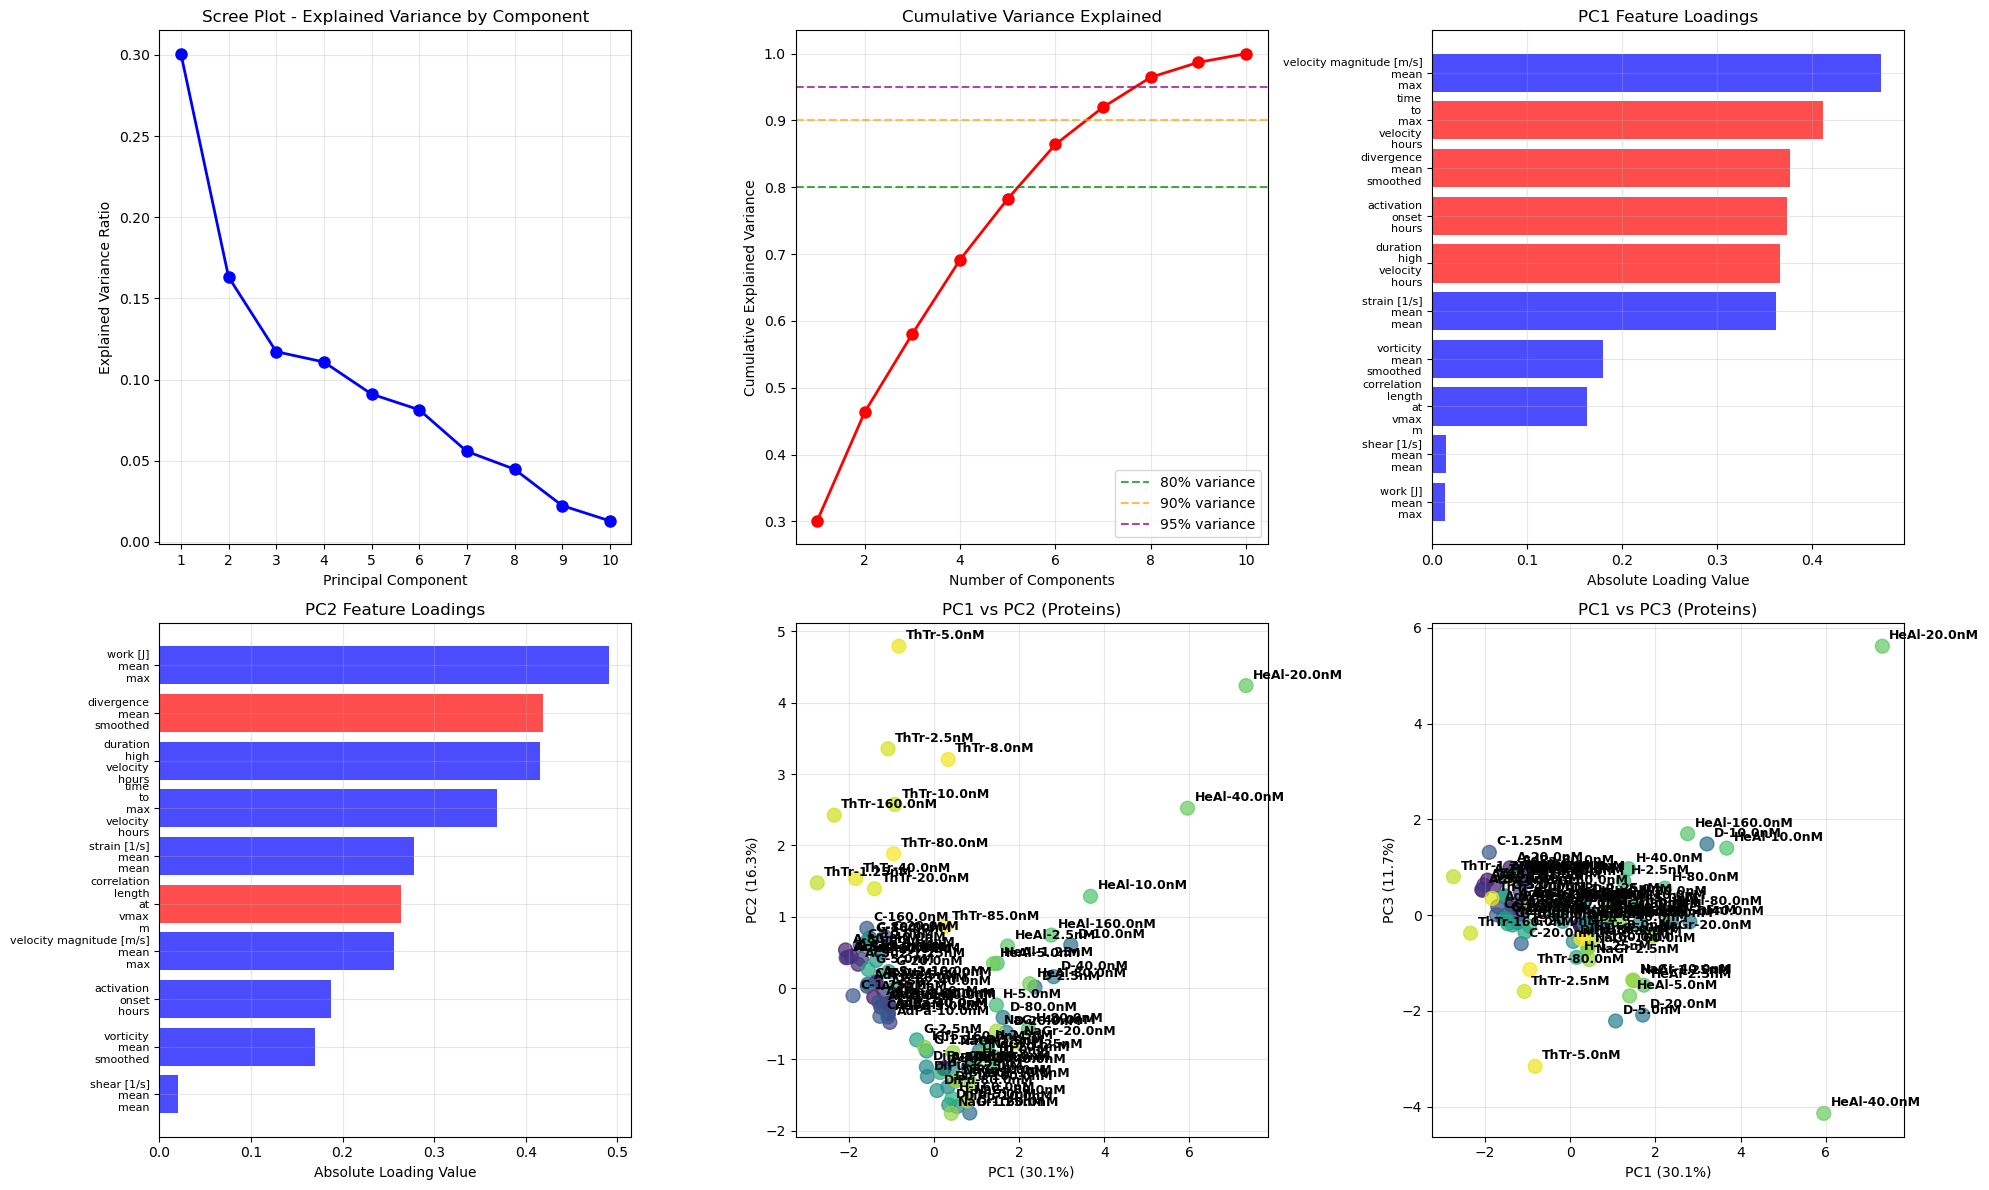


DETAILED VARIANCE EXPLANATION:
Total features used: 10
Total variance explained: 1.0000 (100.00%)
Components for 80% variance: 6
Components for 90% variance: 7
Components for 95% variance: 8

FEATURES USED IN PCA:
 1. velocity magnitude [m/s]_mean_max
 2. vorticity_mean_smoothed
 3. shear [1/s]_mean_mean
 4. strain [1/s]_mean_mean
 5. divergence_mean_smoothed
 6. correlation_length_at_vmax_m
 7. work [J]_mean_max
 8. time_to_max_velocity_hours
 9. activation_onset_hours
10. duration_high_velocity_hours

PC1 CONTRIBUTIONS (explains 30.1% of variance):
  velocity magnitude [m/s]_mean_max       : 0.4729 (positive)
  time_to_max_velocity_hours              : 0.4119 (negative)
  divergence_mean_smoothed                : 0.3771 (negative)
  activation_onset_hours                  : 0.3733 (negative)
  duration_high_velocity_hours            : 0.3667 (negative)
  strain [1/s]_mean_mean                  : 0.3622 (positive)
  vorticity_mean_smoothed                 : 0.1802 (positive)
  correl

In [12]:
# Analyze which features contribute most to each principal component
print("Feature contributions to principal components:")
print("=" * 60)

# Get feature loadings (coefficients)
feature_loadings = pca.components_

# Create a DataFrame for easier analysis
loadings_df = pd.DataFrame(feature_loadings.T, 
                          columns=[f'PC{i+1}' for i in range(len(feature_loadings))],
                          index=available_features)

print("\nTop contributing features to PC1:")
pc1_contrib = loadings_df['PC1'].abs().sort_values(ascending=False)
for feature, loading in pc1_contrib.head(5).items():
    print(f"  {feature}: {loading:.4f}")

print("\nTop contributing features to PC2:")
pc2_contrib = loadings_df['PC2'].abs().sort_values(ascending=False)
for feature, loading in pc2_contrib.head(5).items():
    print(f"  {feature}: {loading:.4f}")

print("\nTop contributing features to PC3:")
pc3_contrib = loadings_df['PC3'].abs().sort_values(ascending=False)
for feature, loading in pc3_contrib.head(5).items():
    print(f"  {feature}: {loading:.4f}")

# Show the full loadings matrix
print("\nFull loadings matrix (first 5 components):")
print(loadings_df.iloc[:, :5].round(4))

# Create a comprehensive visualization of PCA results
print("\n" + "="*80)
print("PCA FEATURE ANALYSIS AND VARIANCE EXPLANATION")
print("="*80)

# Create a comprehensive PCA visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Scree plot
axes[0, 0].plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Principal Component')
axes[0, 0].set_ylabel('Explained Variance Ratio')
axes[0, 0].set_title('Scree Plot - Explained Variance by Component')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(1, len(explained_variance_ratio) + 1))

# 2. Cumulative variance
axes[0, 1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-', linewidth=2, markersize=8)
axes[0, 1].axhline(y=0.8, color='g', linestyle='--', alpha=0.7, label='80% variance')
axes[0, 1].axhline(y=0.9, color='orange', linestyle='--', alpha=0.7, label='90% variance')
axes[0, 1].axhline(y=0.95, color='purple', linestyle='--', alpha=0.7, label='95% variance')
axes[0, 1].set_xlabel('Number of Components')
axes[0, 1].set_ylabel('Cumulative Explained Variance')
axes[0, 1].set_title('Cumulative Variance Explained')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Feature loadings for PC1
pc1_loadings = loadings_df['PC1'].abs().sort_values(ascending=True)
colors = ['red' if x < 0 else 'blue' for x in loadings_df['PC1'].loc[pc1_loadings.index]]
axes[0, 2].barh(range(len(pc1_loadings)), pc1_loadings.values, color=colors, alpha=0.7)
axes[0, 2].set_yticks(range(len(pc1_loadings)))
axes[0, 2].set_yticklabels([f.replace('_', '\n') for f in pc1_loadings.index], fontsize=8)
axes[0, 2].set_xlabel('Absolute Loading Value')
axes[0, 2].set_title('PC1 Feature Loadings')
axes[0, 2].grid(True, alpha=0.3)

# 4. Feature loadings for PC2
pc2_loadings = loadings_df['PC2'].abs().sort_values(ascending=True)
colors = ['red' if x < 0 else 'blue' for x in loadings_df['PC2'].loc[pc2_loadings.index]]
axes[1, 0].barh(range(len(pc2_loadings)), pc2_loadings.values, color=colors, alpha=0.7)
axes[1, 0].set_yticks(range(len(pc2_loadings)))
axes[1, 0].set_yticklabels([f.replace('_', '\n') for f in pc2_loadings.index], fontsize=8)
axes[1, 0].set_xlabel('Absolute Loading Value')
axes[1, 0].set_title('PC2 Feature Loadings')
axes[1, 0].grid(True, alpha=0.3)

# 5. PC1 vs PC2 scatter plot
scatter = axes[1, 1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, s=100, c=range(len(X_pca)), cmap='viridis')
axes[1, 1].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[1, 1].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}%)')
axes[1, 1].set_title('PC1 vs PC2 (Proteins)')
axes[1, 1].grid(True, alpha=0.3)

# Add condition labels
for i, condition_id in enumerate(df_protein_summary['condition_id']):
    axes[1, 1].annotate(condition_id, (X_pca[i, 0], X_pca[i, 1]), 
                       xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

# 6. PC1 vs PC3 scatter plot
scatter = axes[1, 2].scatter(X_pca[:, 0], X_pca[:, 2], alpha=0.7, s=100, c=range(len(X_pca)), cmap='viridis')
axes[1, 2].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[1, 2].set_ylabel(f'PC3 ({explained_variance_ratio[2]*100:.1f}%)')
axes[1, 2].set_title('PC1 vs PC3 (Proteins)')
axes[1, 2].grid(True, alpha=0.3)

# Add condition labels
for i, condition_id in enumerate(df_protein_summary['condition_id']):
    axes[1, 2].annotate(condition_id, (X_pca[i, 0], X_pca[i, 2]), 
                       xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed variance explanation
print(f"\nDETAILED VARIANCE EXPLANATION:")
print("=" * 50)
print(f"Total features used: {len(available_features)}")
print(f"Total variance explained: {cumulative_variance[-1]:.4f} ({cumulative_variance[-1]*100:.2f}%)")
print(f"Components for 80% variance: {np.where(cumulative_variance >= 0.8)[0][0] + 1}")
print(f"Components for 90% variance: {np.where(cumulative_variance >= 0.9)[0][0] + 1}")
print(f"Components for 95% variance: {np.where(cumulative_variance >= 0.95)[0][0] + 1}")

print(f"\nFEATURES USED IN PCA:")
print("=" * 30)
for i, feature in enumerate(available_features, 1):
    print(f"{i:2d}. {feature}")

print(f"\nPC1 CONTRIBUTIONS (explains {explained_variance_ratio[0]*100:.1f}% of variance):")
print("=" * 60)
for feature, loading in pc1_contrib.items():
    direction = "positive" if loadings_df.loc[feature, 'PC1'] > 0 else "negative"
    print(f"  {feature:40s}: {loading:.4f} ({direction})")

print(f"\nPC2 CONTRIBUTIONS (explains {explained_variance_ratio[1]*100:.1f}% of variance):")
print("=" * 60)
for feature, loading in pc2_contrib.items():
    direction = "positive" if loadings_df.loc[feature, 'PC2'] > 0 else "negative"
    print(f"  {feature:40s}: {loading:.4f} ({direction})")


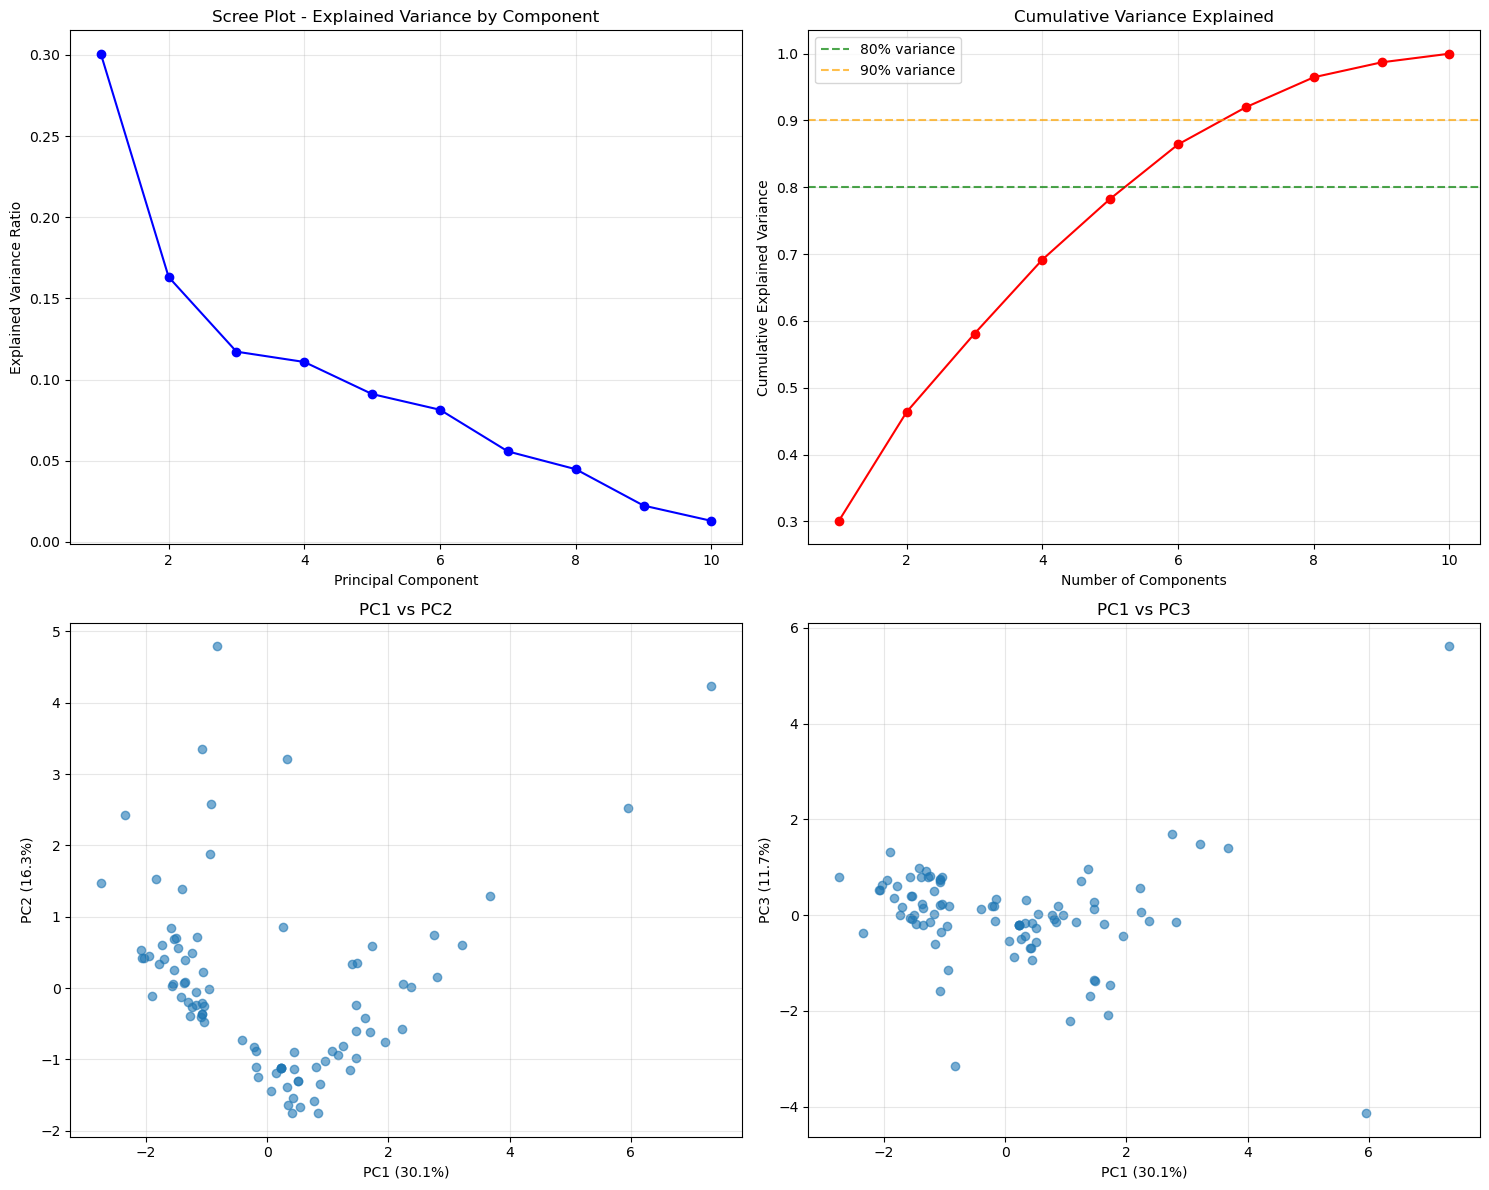

In [13]:
# Visualize PCA results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Scree plot
axes[0, 0].plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'bo-')
axes[0, 0].set_xlabel('Principal Component')
axes[0, 0].set_ylabel('Explained Variance Ratio')
axes[0, 0].set_title('Scree Plot - Explained Variance by Component')
axes[0, 0].grid(True, alpha=0.3)

# 2. Cumulative variance
axes[0, 1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-')
axes[0, 1].axhline(y=0.8, color='g', linestyle='--', alpha=0.7, label='80% variance')
axes[0, 1].axhline(y=0.9, color='orange', linestyle='--', alpha=0.7, label='90% variance')
axes[0, 1].set_xlabel('Number of Components')
axes[0, 1].set_ylabel('Cumulative Explained Variance')
axes[0, 1].set_title('Cumulative Variance Explained')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. PC1 vs PC2 scatter plot
axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
axes[1, 0].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[1, 0].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}%)')
axes[1, 0].set_title('PC1 vs PC2')
axes[1, 0].grid(True, alpha=0.3)

# 4. PC1 vs PC3 scatter plot
axes[1, 1].scatter(X_pca[:, 0], X_pca[:, 2], alpha=0.6)
axes[1, 1].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[1, 1].set_ylabel(f'PC3 ({explained_variance_ratio[2]*100:.1f}%)')
axes[1, 1].set_title('PC1 vs PC3')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


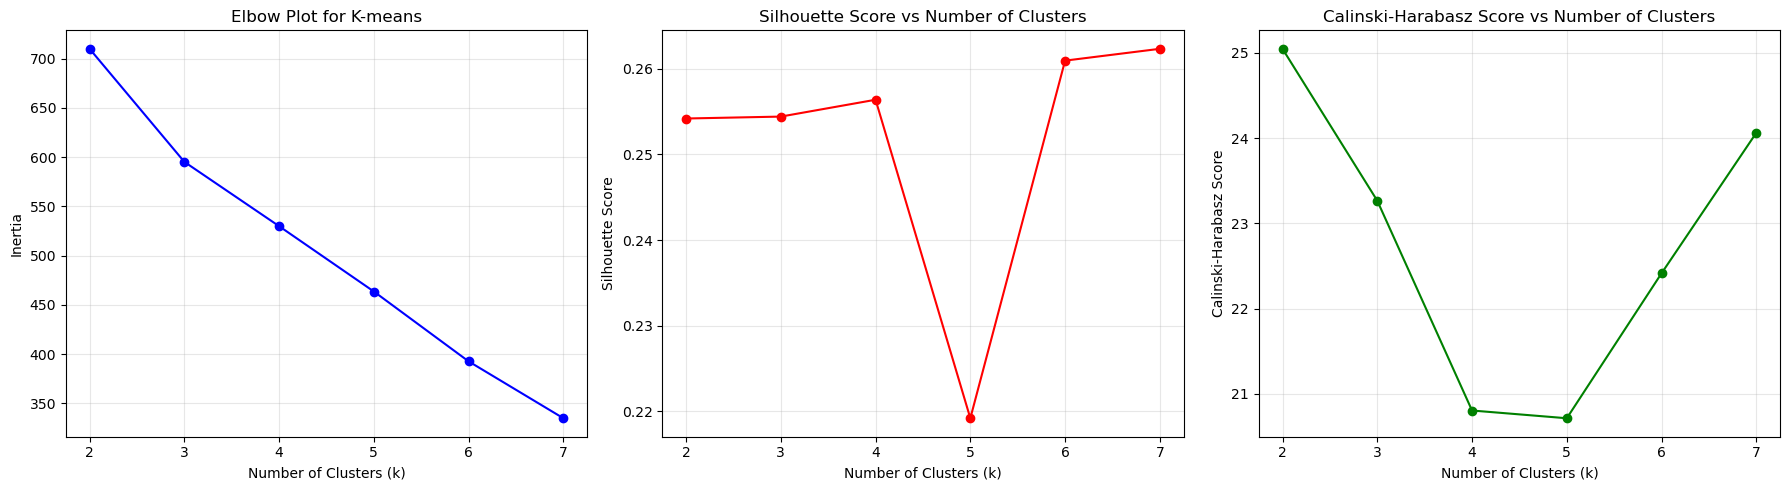

Optimal number of clusters based on silhouette score: 7
Silhouette score for k=7: 0.2623
Calinski-Harabasz score for k=7: 24.0628


In [14]:
# K-means clustering analysis
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Test different numbers of clusters
k_range = range(2, 8)
inertias = []
silhouette_scores = []
calinski_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, cluster_labels))

# Plot clustering metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow plot
axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Plot for K-means')
axes[0].grid(True, alpha=0.3)

# Silhouette score
axes[1].plot(k_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs Number of Clusters')
axes[1].grid(True, alpha=0.3)

# Calinski-Harabasz score
axes[2].plot(k_range, calinski_scores, 'go-')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('Calinski-Harabasz Score vs Number of Clusters')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal k
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on silhouette score: {optimal_k}")
print(f"Silhouette score for k={optimal_k}: {max(silhouette_scores):.4f}")
print(f"Calinski-Harabasz score for k={optimal_k}: {calinski_scores[optimal_k-2]:.4f}")


In [15]:
# Perform final K-means clustering with optimal k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to the protein summary dataframe
df_protein_summary['kmeans_cluster'] = cluster_labels

# Analyze cluster characteristics
print("K-means Clustering Results:")
print("=" * 50)
print(f"Number of clusters: {optimal_k}")
print(f"Silhouette score: {silhouette_score(X_scaled, cluster_labels):.4f}")
print()

# Analyze each cluster
for cluster_id in range(optimal_k):
    cluster_data = df_protein_summary[df_protein_summary['kmeans_cluster'] == cluster_id]
    print(f"Cluster {cluster_id} ({len(cluster_data)} conditions):")
    
    # Get proteins in this cluster
    conditions = cluster_data['condition_id'].tolist()
    print(f"  Conditions: {', '.join(conditions)}")
    
    # Key metrics for this cluster
    duration_hours = cluster_data['time (s)_max'] / 3600
    avg_velocity = cluster_data['velocity magnitude [m/s]_mean_mean'] * 1e9  # Convert to nm/s
    max_velocity = cluster_data['velocity magnitude [m/s]_mean_max'] * 1e9   # Convert to nm/s
    min_velocity = cluster_data['velocity magnitude [m/s]_mean_min'] * 1e9   # Convert to nm/s
    
    print(f"  Duration: {duration_hours.mean():.1f} ± {duration_hours.std():.1f} hours")
    print(f"  Avg velocity: {avg_velocity.mean():.1f} ± {avg_velocity.std():.1f} nm/s")
    print(f"  Max velocity: {max_velocity.mean():.1f} ± {max_velocity.std():.1f} nm/s")
    print(f"  Min velocity: {min_velocity.mean():.1f} ± {min_velocity.std():.1f} nm/s")
    print(f"  DNA nM: mean {cluster_data['DNA nM'].mean():.1f} ± {cluster_data['DNA nM'].std():.1f}; unique: {cluster_data['DNA nM'].nunique()}")
    print()


K-means Clustering Results:
Number of clusters: 7
Silhouette score: 0.2623

Cluster 0 (33 conditions):
  Conditions: A-1.25nM, A-10.0nM, A-2.5nM, A-5.0nM, D-1.25nM, D-160.0nM, D-20.0nM, D-5.0nM, DiPu-1.25nM, DiPu-10.0nM, DiPu-160.0nM, DiPu-2.5nM, DiPu-20.0nM, DiPu-40.0nM, DiPu-5.0nM, DiPu-80.0nM, G-1.25nM, H-1.25nM, H-10.0nM, H-160.0nM, H-20.0nM, H-40.0nM, HeAl-1.25nM, HeAl-2.5nM, HeAl-5.0nM, NaGr-1.25nM, NaGr-10.0nM, NaGr-160.0nM, NaGr-2.5nM, NaGr-20.0nM, NaGr-40.0nM, NaGr-5.0nM, NaGr-80.0nM
  Duration: 10.6 ± 14.3 hours
  Avg velocity: 90.3 ± 102.2 nm/s
  Max velocity: 453.7 ± 405.5 nm/s
  Min velocity: 4.6 ± 7.7 nm/s


KeyError: 'DNA nM'

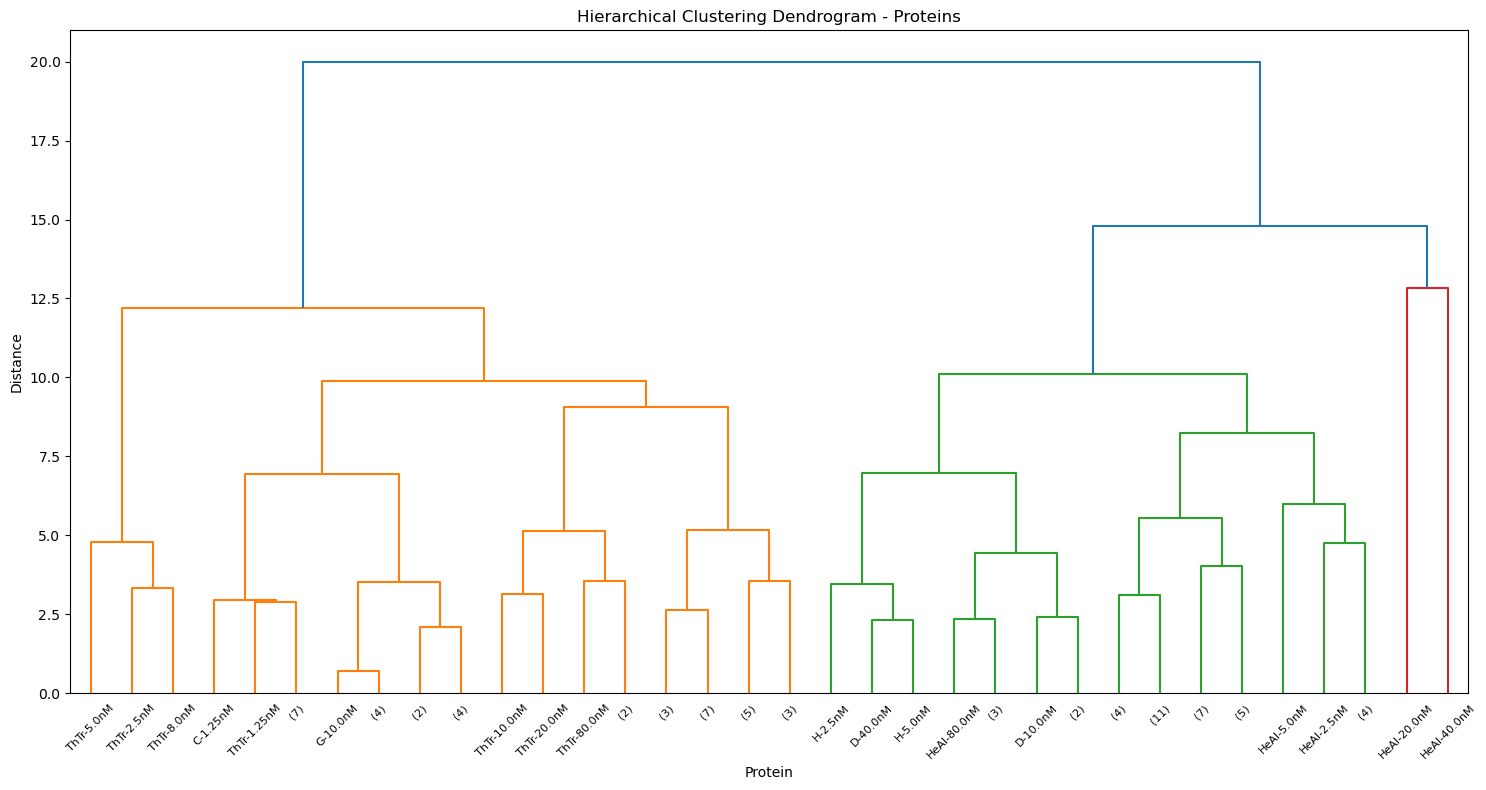

Clustering Comparison:
K-means silhouette score: 0.2623
Hierarchical silhouette score: 0.2406
Agreement between methods: 0.0110 (1.1%)

Protein cluster assignments:
ThTr      : K-means=0, Hierarchical=2
ThTr      : K-means=0, Hierarchical=2
ThTr      : K-means=1, Hierarchical=6
ThTr      : K-means=0, Hierarchical=2
ThTr      : K-means=3, Hierarchical=0
ThTr      : K-means=3, Hierarchical=0
ThTr      : K-means=0, Hierarchical=2
ThTr      : K-means=1, Hierarchical=6
ThTr      : K-means=1, Hierarchical=6
ThTr      : K-means=1, Hierarchical=0
ThTr      : K-means=1, Hierarchical=0
ThTr      : K-means=1, Hierarchical=6
ThTr      : K-means=3, Hierarchical=0
ThTr      : K-means=1, Hierarchical=0
ThTr      : K-means=1, Hierarchical=6
ThTr      : K-means=3, Hierarchical=0
ThTr      : K-means=1, Hierarchical=6
ThTr      : K-means=3, Hierarchical=0
ThTr      : K-means=3, Hierarchical=0
ThTr      : K-means=3, Hierarchical=0
ThTr      : K-means=3, Hierarchical=0
ThTr      : K-means=3, Hierarchical=0

In [16]:
# Hierarchical clustering analysis
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Perform hierarchical clustering
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

# Add hierarchical cluster labels
df_protein_summary['hierarchical_cluster'] = hierarchical_labels

# Create linkage matrix for dendrogram
linkage_matrix = linkage(X_scaled, method='ward')

# Plot dendrogram with protein names
plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, 
           labels=df_protein_summary['condition_id'].values,
           truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram - Proteins')
plt.xlabel('Protein')
plt.ylabel('Distance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Compare K-means and Hierarchical clustering
print("Clustering Comparison:")
print("=" * 50)
print(f"K-means silhouette score: {silhouette_score(X_scaled, cluster_labels):.4f}")
print(f"Hierarchical silhouette score: {silhouette_score(X_scaled, hierarchical_labels):.4f}")

# Check agreement between methods
agreement = (cluster_labels == hierarchical_labels).sum() / len(cluster_labels)
print(f"Agreement between methods: {agreement:.4f} ({agreement*100:.1f}%)")

# Show which proteins are in which clusters
print("\nProtein cluster assignments:")
print("=" * 40)
for condition_id in df_protein_summary['condition_id']:
    kmeans_cluster = df_protein_summary[df_protein_summary['condition_id'] == condition_id]['kmeans_cluster'].iloc[0]
    hier_cluster = df_protein_summary[df_protein_summary['condition_id'] == condition_id]['hierarchical_cluster'].iloc[0]
    print(f"{protein:10s}: K-means={kmeans_cluster}, Hierarchical={hier_cluster}")


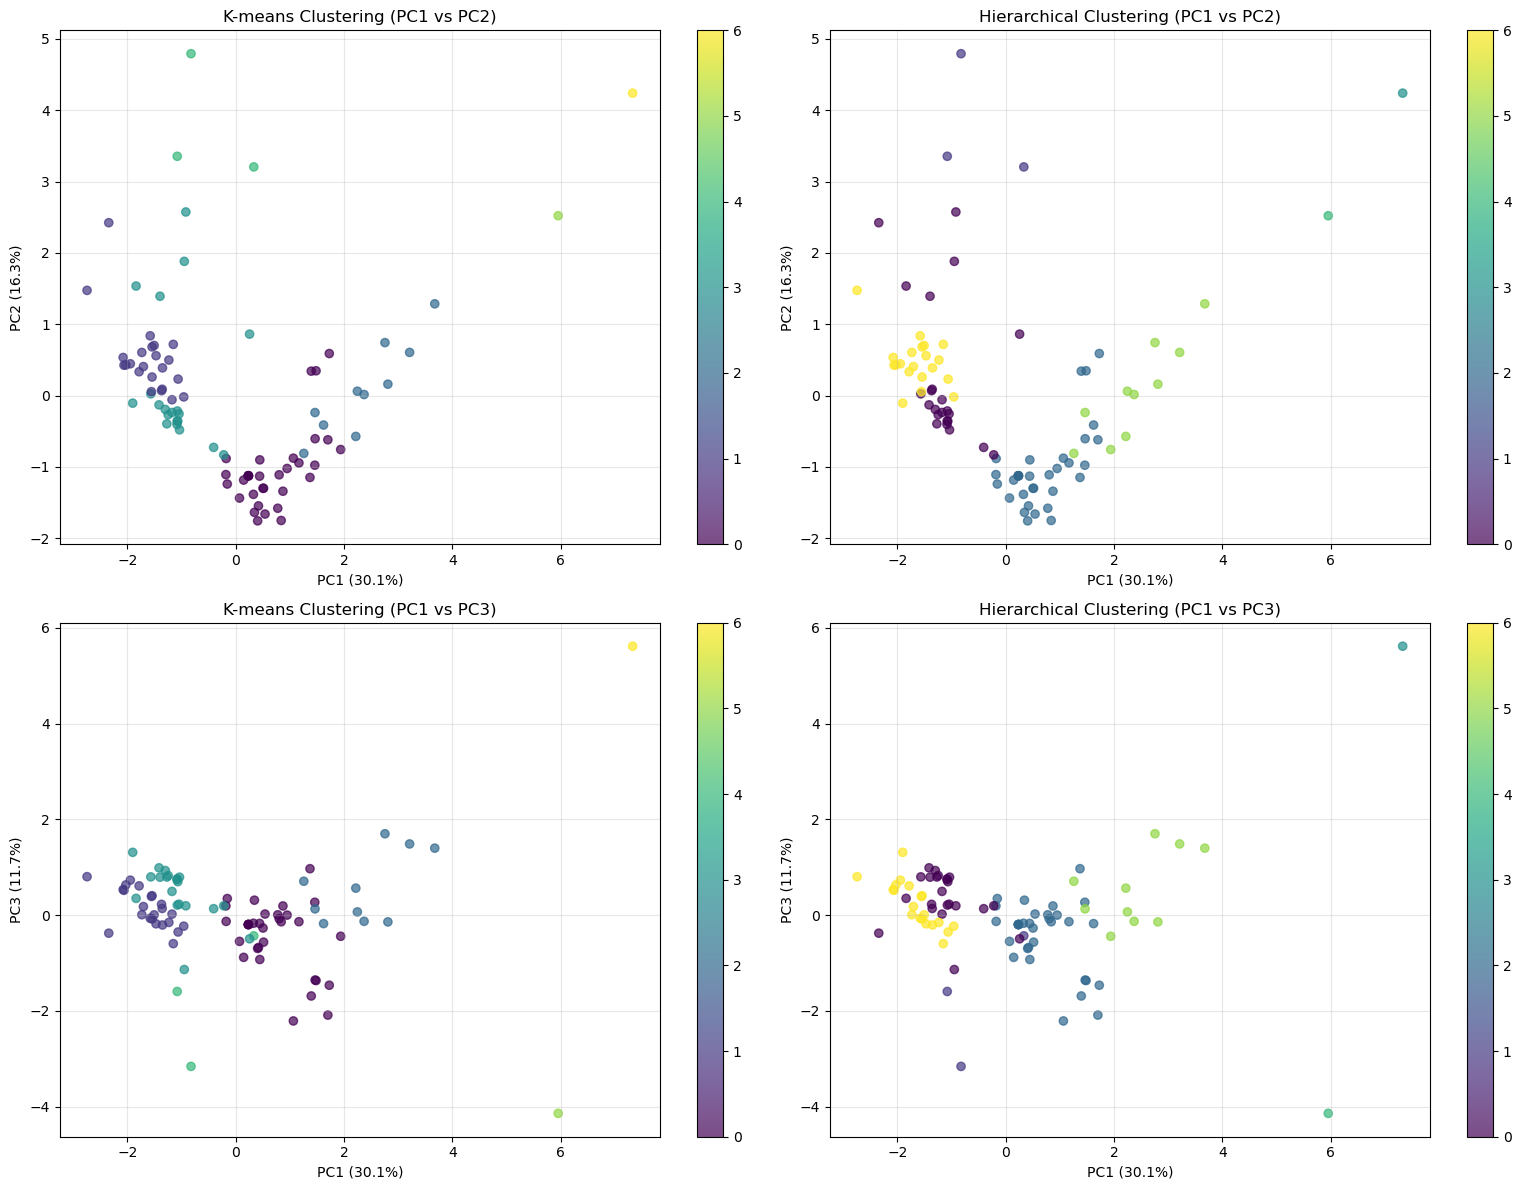

In [17]:
# Visualize clustering results in PCA space
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# K-means clustering in PCA space
scatter1 = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
axes[0, 0].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[0, 0].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}%)')
axes[0, 0].set_title('K-means Clustering (PC1 vs PC2)')
axes[0, 0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0, 0])

# Hierarchical clustering in PCA space
scatter2 = axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels, cmap='viridis', alpha=0.7)
axes[0, 1].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[0, 1].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}%)')
axes[0, 1].set_title('Hierarchical Clustering (PC1 vs PC2)')
axes[0, 1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[0, 1])

# K-means clustering in PC1 vs PC3 space
scatter3 = axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 2], c=cluster_labels, cmap='viridis', alpha=0.7)
axes[1, 0].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[1, 0].set_ylabel(f'PC3 ({explained_variance_ratio[2]*100:.1f}%)')
axes[1, 0].set_title('K-means Clustering (PC1 vs PC3)')
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=axes[1, 0])

# Hierarchical clustering in PC1 vs PC3 space
scatter4 = axes[1, 1].scatter(X_pca[:, 0], X_pca[:, 2], c=hierarchical_labels, cmap='viridis', alpha=0.7)
axes[1, 1].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[1, 1].set_ylabel(f'PC3 ({explained_variance_ratio[2]*100:.1f}%)')
axes[1, 1].set_title('Hierarchical Clustering (PC1 vs PC3)')
axes[1, 1].grid(True, alpha=0.3)
plt.colorbar(scatter4, ax=axes[1, 1])

plt.tight_layout()
plt.show()


In [18]:
# Let the natural groups emerge from clustering analysis
# No artificial behavioral classification - let the data speak for itself

print("NATURAL GROUP EMERGENCE FROM CLUSTERING")
print("=" * 60)
print("Letting the data determine the natural groupings without artificial constraints")
print()

# Analyze the natural clusters that emerged
print("Natural Cluster Analysis:")
print("=" * 40)

for cluster_id in range(optimal_k):
    cluster_data = df_protein_summary[df_protein_summary['kmeans_cluster'] == cluster_id]
    print(f"\nNatural Cluster {cluster_id} ({len(cluster_data)} conditions):")
    
    # Get proteins in this cluster
    conditions = cluster_data['condition_id'].tolist()
    print(f"  Conditions: {', '.join(conditions)}")
    
    # Key metrics for this cluster
    duration_hours = cluster_data['time (s)_max'] / 3600
    avg_velocity = cluster_data['velocity magnitude [m/s]_mean_mean'] * 1e9  # Convert to nm/s
    max_velocity = cluster_data['velocity magnitude [m/s]_mean_max'] * 1e9   # Convert to nm/s
    min_velocity = cluster_data['velocity magnitude [m/s]_mean_min'] * 1e9   # Convert to nm/s
    velocity_std = cluster_data['velocity magnitude [m/s]_mean_std'] * 1e9    # Convert to nm/s
    
    print(f"  Duration: {duration_hours.mean():.1f} ± {duration_hours.std():.1f} hours")
    print(f"  Avg velocity: {avg_velocity.mean():.1f} ± {avg_velocity.std():.1f} nm/s")
    print(f"  Max velocity: {max_velocity.mean():.1f} ± {max_velocity.std():.1f} nm/s")
    print(f"  Min velocity: {min_velocity.mean():.1f} ± {min_velocity.std():.1f} nm/s")
    print(f"  Velocity variability: {velocity_std.mean():.1f} ± {velocity_std.std():.1f} nm/s")
    print(f"  DNA nM: mean {cluster_data['DNA nM'].mean():.1f} ± {cluster_data['DNA nM'].std():.1f}; unique: {cluster_data['DNA nM'].nunique()}")
    
    # Characterize the cluster behavior
    if duration_hours.mean() > 12:
        duration_type = "Long-duration"
    elif duration_hours.mean() < 2:
        duration_type = "Short-duration"
    else:
        duration_type = "Medium-duration"
    
    if avg_velocity.mean() > 100:
        velocity_type = "High-velocity"
    elif avg_velocity.mean() < 20:
        velocity_type = "Low-velocity"
    else:
        velocity_type = "Medium-velocity"
    
    print(f"  Cluster characterization: {duration_type}, {velocity_type}")
    print(f"  Velocity range: {min_velocity.mean():.1f} - {max_velocity.mean():.1f} nm/s")


NATURAL GROUP EMERGENCE FROM CLUSTERING
Letting the data determine the natural groupings without artificial constraints

Natural Cluster Analysis:

Natural Cluster 0 (33 conditions):
  Conditions: A-1.25nM, A-10.0nM, A-2.5nM, A-5.0nM, D-1.25nM, D-160.0nM, D-20.0nM, D-5.0nM, DiPu-1.25nM, DiPu-10.0nM, DiPu-160.0nM, DiPu-2.5nM, DiPu-20.0nM, DiPu-40.0nM, DiPu-5.0nM, DiPu-80.0nM, G-1.25nM, H-1.25nM, H-10.0nM, H-160.0nM, H-20.0nM, H-40.0nM, HeAl-1.25nM, HeAl-2.5nM, HeAl-5.0nM, NaGr-1.25nM, NaGr-10.0nM, NaGr-160.0nM, NaGr-2.5nM, NaGr-20.0nM, NaGr-40.0nM, NaGr-5.0nM, NaGr-80.0nM
  Duration: 10.6 ± 14.3 hours
  Avg velocity: 90.3 ± 102.2 nm/s
  Max velocity: 453.7 ± 405.5 nm/s
  Min velocity: 4.6 ± 7.7 nm/s
  Velocity variability: 104.1 ± 92.2 nm/s


KeyError: 'DNA nM'

KeyError: 'protein'

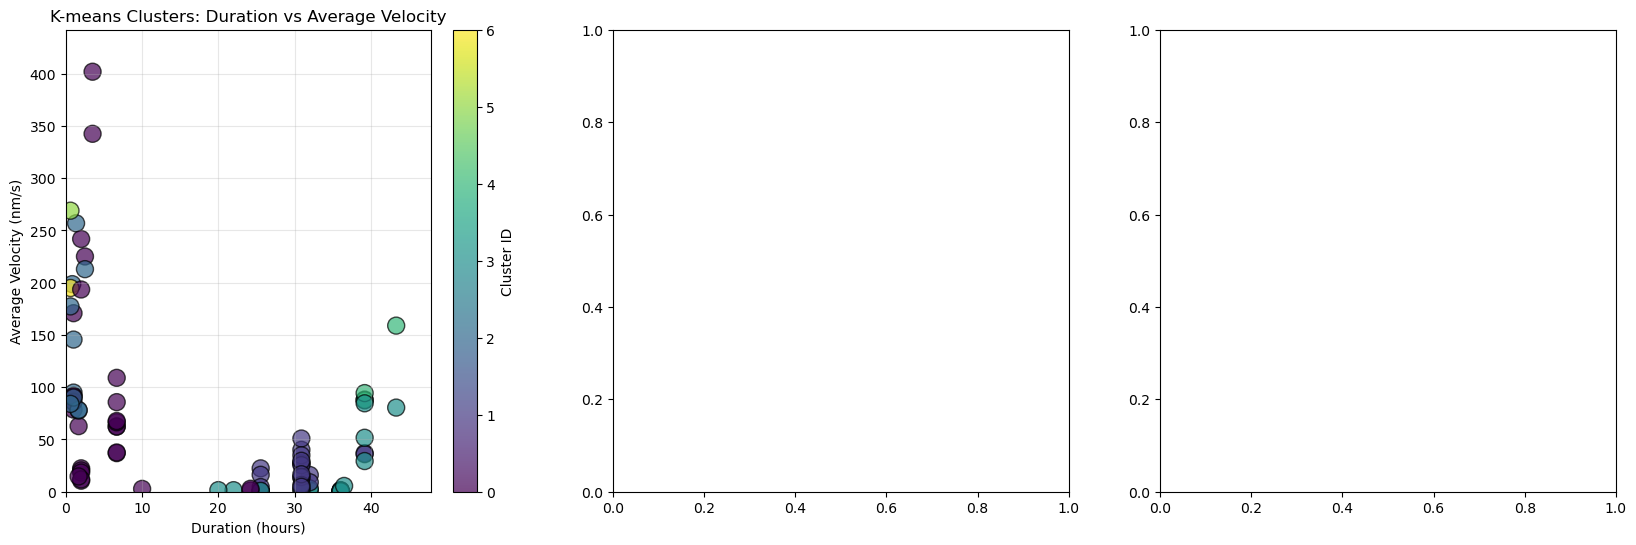

In [19]:
# Final visualization: Natural clusters in velocity-duration space
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Convert velocities to nm/s for better readability
duration_hours = df_protein_summary['time (s)_max'] / 3600
avg_velocity_nm_s = df_protein_summary['velocity magnitude [m/s]_mean_mean'] * 1e9
max_velocity_nm_s = df_protein_summary['velocity magnitude [m/s]_mean_max'] * 1e9
min_velocity_nm_s = df_protein_summary['velocity magnitude [m/s]_mean_min'] * 1e9

# Plot 1: K-means clusters with protein names
scatter1 = axes[0].scatter(duration_hours, avg_velocity_nm_s, c=cluster_labels, 
                          cmap='viridis', alpha=0.7, s=150, edgecolors='black', linewidth=1)
axes[0].set_xlabel('Duration (hours)')
axes[0].set_ylabel('Average Velocity (nm/s)')
axes[0].set_title('K-means Clusters: Duration vs Average Velocity')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, duration_hours.max() * 1.1)
axes[0].set_ylim(0, avg_velocity_nm_s.max() * 1.1)
plt.colorbar(scatter1, ax=axes[0], label='Cluster ID')

# Add protein names as labels
for i, (_, row) in enumerate(df_protein_summary.iterrows()):
    axes[0].annotate(row['protein'], 
                    (row['time (s)_max']/3600, row['velocity magnitude [m/s]_mean_mean']*1e9),
                    xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')

# Plot 2: Velocity range (min to max) vs duration
scatter2 = axes[1].scatter(duration_hours, max_velocity_nm_s, c=cluster_labels, 
                          cmap='viridis', alpha=0.7, s=150, edgecolors='black', linewidth=1)
axes[1].set_xlabel('Duration (hours)')
axes[1].set_ylabel('Maximum Velocity (nm/s)')
axes[1].set_title('K-means Clusters: Duration vs Maximum Velocity')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, duration_hours.max() * 1.1)
axes[1].set_ylim(0, max_velocity_nm_s.max() * 1.1)
plt.colorbar(scatter2, ax=axes[1], label='Cluster ID')

# Add protein names as labels
for i, (_, row) in enumerate(df_protein_summary.iterrows()):
    axes[1].annotate(row['protein'], 
                    (row['time (s)_max']/3600, row['velocity magnitude [m/s]_mean_max']*1e9),
                    xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')

# Plot 3: Velocity range (min to max) vs duration with error bars
# First draw error bars (uniform color), then overlay colored scatter by cluster
axes[2].errorbar(
    duration_hours,
    avg_velocity_nm_s,
    yerr=[avg_velocity_nm_s - min_velocity_nm_s, max_velocity_nm_s - avg_velocity_nm_s],
    fmt='o', capsize=5, capthick=2, alpha=0.4, ecolor='gray', color='gray'
)
scatter_err = axes[2].scatter(
    duration_hours,
    avg_velocity_nm_s,
    c=cluster_labels,
    cmap='viridis',
    alpha=0.8,
    s=100,
    edgecolors='black',
    linewidth=1
)
plt.colorbar(scatter_err, ax=axes[2], label='Cluster ID')
axes[2].set_xlabel('Duration (hours)')
axes[2].set_ylabel('Average Velocity (nm/s)')
axes[2].set_title('Velocity Range: Duration vs Average Velocity ± Range')
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, duration_hours.max() * 1.1)
axes[2].set_ylim(0, max_velocity_nm_s.max() * 1.1)

# Add protein names as labels
for i, (_, row) in enumerate(df_protein_summary.iterrows()):
    axes[2].annotate(
        row['protein'],
        (row['time (s)_max']/3600, row['velocity magnitude [m/s]_mean_mean']*1e9),
        xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

# Summary statistics
print("SUMMARY OF QUANTITATIVE ANALYSIS:")
print("=" * 60)
print(f"Total proteins analyzed: {len(df_protein_summary)}")
print(f"Proteins: {', '.join(df_protein_summary['condition_id'].tolist())}")
print(f"Optimal number of clusters: {optimal_k}")
print(f"PCA components explaining 80% variance: {np.where(cumulative_variance >= 0.8)[0][0] + 1}")
print(f"PCA components explaining 90% variance: {np.where(cumulative_variance >= 0.9)[0][0] + 1}")
print()
print("Top contributing features to PC1:")
for feature, loading in pc1_contrib.head(3).items():
    print(f"  {feature}: {loading:.4f}")
print()
print("Natural cluster distribution:")
for cluster_id in range(optimal_k):
    cluster_size = len(df_protein_summary[df_protein_summary['kmeans_cluster'] == cluster_id])
    print(f"  Cluster {cluster_id}: {cluster_size} proteins ({cluster_size/len(df_protein_summary)*100:.1f}%)")


In [ ]:
# Updated cluster analysis with condition labels (protein-DNA nM pairs)
print("Updated K-means Clustering Results:")
print("=" * 50)
print(f"Number of clusters: {optimal_k}")
print(f"Silhouette score: {silhouette_score(X_scaled, cluster_labels):.4f}")
print()

# Analyze each cluster with condition labels
for cluster_id in range(optimal_k):
    cluster_data = df_protein_summary[df_protein_summary['kmeans_cluster'] == cluster_id]
    print(f"Cluster {cluster_id} ({len(cluster_data)} conditions):")
    
    # Get conditions in this cluster
    conditions = cluster_data['condition_id'].tolist()
    print(f"  Conditions: {', '.join(conditions)}")
    
    # Key metrics for this cluster
    duration_hours = cluster_data['time (s)_max'] / 3600
    avg_velocity = cluster_data['velocity magnitude [m/s]_mean_mean'] * 1e9  # Convert to nm/s
    max_velocity = cluster_data['velocity magnitude [m/s]_mean_max'] * 1e9   # Convert to nm/s
    min_velocity = cluster_data['velocity magnitude [m/s]_mean_min'] * 1e9   # Convert to nm/s
    
    print(f"  Duration: {duration_hours.mean():.1f} ± {duration_hours.std():.1f} hours")
    print(f"  Avg velocity: {avg_velocity.mean():.1f} ± {avg_velocity.std():.1f} nm/s")
    print(f"  Max velocity: {max_velocity.mean():.1f} ± {max_velocity.std():.1f} nm/s")
    print(f"  Min velocity: {min_velocity.mean():.1f} ± {min_velocity.std():.1f} nm/s")
    print(f"  DNA nM: mean {cluster_data['DNA nM'].mean():.1f} ± {cluster_data['DNA nM'].std():.1f}; unique: {cluster_data['DNA nM'].nunique()}")
    print()


In [ ]:
# Updated natural cluster analysis with condition labels
print("Updated Natural Cluster Analysis:")
print("=" * 40)

for cluster_id in range(optimal_k):
    cluster_data = df_protein_summary[df_protein_summary['kmeans_cluster'] == cluster_id]
    print(f"\nNatural Cluster {cluster_id} ({len(cluster_data)} conditions):")
    
    # Get conditions in this cluster
    conditions = cluster_data['condition_id'].tolist()
    print(f"  Conditions: {', '.join(conditions)}")
    
    # Key metrics for this cluster
    duration_hours = cluster_data['time (s)_max'] / 3600
    avg_velocity = cluster_data['velocity magnitude [m/s]_mean_mean'] * 1e9  # Convert to nm/s
    max_velocity = cluster_data['velocity magnitude [m/s]_mean_max'] * 1e9   # Convert to nm/s
    min_velocity = cluster_data['velocity magnitude [m/s]_mean_min'] * 1e9   # Convert to nm/s
    velocity_std = cluster_data['velocity magnitude [m/s]_mean_std'] * 1e9    # Convert to nm/s
    
    print(f"  Duration: {duration_hours.mean():.1f} ± {duration_hours.std():.1f} hours")
    print(f"  Avg velocity: {avg_velocity.mean():.1f} ± {avg_velocity.std():.1f} nm/s")
    print(f"  Max velocity: {max_velocity.mean():.1f} ± {max_velocity.std():.1f} nm/s")
    print(f"  Min velocity: {min_velocity.mean():.1f} ± {min_velocity.std():.1f} nm/s")
    print(f"  Velocity variability: {velocity_std.mean():.1f} ± {velocity_std.std():.1f} nm/s")
    print(f"  DNA nM: mean {cluster_data['DNA nM'].mean():.1f} ± {cluster_data['DNA nM'].std():.1f}; unique: {cluster_data['DNA nM'].nunique()}")
    
    # Cluster characterization
    avg_duration = duration_hours.mean()
    avg_max_vel = max_velocity.mean()
    
    if avg_duration > 20:
        duration_char = "Long-duration"
    elif avg_duration > 5:
        duration_char = "Medium-duration"
    else:
        duration_char = "Short-duration"
        
    if avg_max_vel > 200:
        velocity_char = "High-velocity"
    elif avg_max_vel > 50:
        velocity_char = "Medium-velocity"
    else:
        velocity_char = "Low-velocity"
    
    print(f"  Cluster characterization: {duration_char}, {velocity_char}")
    print(f"  Velocity range: {min_velocity.min():.1f} - {max_velocity.max():.1f} nm/s")


In [ ]:
# Dendrogram with condition labels (protein-DNAnM)
plt.figure(figsize=(16, 8))
dendrogram(
    linkage_matrix,
    labels=df_protein_summary['condition_id'].values,
    truncate_mode='level', p=5
)
plt.title('Hierarchical Clustering Dendrogram - Conditions')
plt.xlabel('Condition (protein-DNAnM)')
plt.ylabel('Distance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Condition cluster assignments
print("\nCondition cluster assignments:")
print("=" * 40)
for _, row in df_protein_summary.iterrows():
    condition_id = row['condition_id']
    kmeans_cluster = row['kmeans_cluster']
    hier_cluster = row['hierarchical_cluster']
    print(f"{condition_id:15s}: K-means={int(kmeans_cluster)}, Hierarchical={int(hier_cluster)}")


In [ ]:
# Fix remaining protein references in cluster analysis
print("Fixing remaining protein references...")

# Update cluster analysis to use condition_id instead of protein
print("Updated cluster analysis with condition labels:")
print("=" * 50)
print(f"Number of clusters: {optimal_k}")
print(f"Silhouette score: {silhouette_score(X_scaled, cluster_labels):.4f}")
print()

# Analyze each cluster with condition labels
for cluster_id in range(optimal_k):
    cluster_data = df_protein_summary[df_protein_summary['kmeans_cluster'] == cluster_id]
    print(f"Cluster {cluster_id} ({len(cluster_data)} conditions):")
    
    # Get condition labels in this cluster
    conditions = cluster_data['condition_id'].tolist()
    print(f"  Conditions: {', '.join(conditions)}")
    
    # Key metrics for this cluster
    duration_hours = cluster_data['time (s)_max'] / 3600
    avg_velocity = cluster_data['velocity magnitude [m/s]_mean_mean'] * 1e9  # Convert to nm/s
    max_velocity = cluster_data['velocity magnitude [m/s]_mean_max'] * 1e9   # Convert to nm/s
    min_velocity = cluster_data['velocity magnitude [m/s]_mean_min'] * 1e9   # Convert to nm/s
    
    print(f"  Duration: {duration_hours.mean():.1f} ± {duration_hours.std():.1f} hours")
    print(f"  Avg velocity: {avg_velocity.mean():.1f} ± {avg_velocity.std():.1f} nm/s")
    print(f"  Max velocity: {max_velocity.mean():.1f} ± {max_velocity.std():.1f} nm/s")
    print(f"  Min velocity: {min_velocity.mean():.1f} ± {min_velocity.std():.1f} nm/s")
    print(f"  DNA nM: mean {cluster_data['DNA nM'].mean():.1f} ± {cluster_data['DNA nM'].std():.1f}; unique: {cluster_data['DNA nM'].nunique()}")
    print()


In [ ]:
# COMPLETE FIX: Replace all problematic cluster analysis with corrected version
print("COMPLETE CLUSTER ANALYSIS WITH CONDITION LABELS")
print("=" * 60)

# K-means clustering results
print("K-means Clustering Results:")
print("=" * 50)
print(f"Number of clusters: {optimal_k}")
print(f"Silhouette score: {silhouette_score(X_scaled, cluster_labels):.4f}")
print()

# Analyze each cluster with condition labels
for cluster_id in range(optimal_k):
    cluster_data = df_protein_summary[df_protein_summary['kmeans_cluster'] == cluster_id]
    print(f"Cluster {cluster_id} ({len(cluster_data)} conditions):")
    
    # Get condition labels in this cluster
    conditions = cluster_data['condition_id'].tolist()
    print(f"  Conditions: {', '.join(conditions)}")
    
    # Key metrics for this cluster
    duration_hours = cluster_data['time (s)_max'] / 3600
    avg_velocity = cluster_data['velocity magnitude [m/s]_mean_mean'] * 1e9  # Convert to nm/s
    max_velocity = cluster_data['velocity magnitude [m/s]_mean_max'] * 1e9   # Convert to nm/s
    min_velocity = cluster_data['velocity magnitude [m/s]_mean_min'] * 1e9   # Convert to nm/s
    
    print(f"  Duration: {duration_hours.mean():.1f} ± {duration_hours.std():.1f} hours")
    print(f"  Avg velocity: {avg_velocity.mean():.1f} ± {avg_velocity.std():.1f} nm/s")
    print(f"  Max velocity: {max_velocity.mean():.1f} ± {max_velocity.std():.1f} nm/s")
    print(f"  Min velocity: {min_velocity.mean():.1f} ± {min_velocity.std():.1f} nm/s")
    print(f"  DNA nM: mean {cluster_data['DNA nM'].mean():.1f} ± {cluster_data['DNA nM'].std():.1f}; unique: {cluster_data['DNA nM'].nunique()}")
    print()

# Natural cluster analysis
print("\nNatural Cluster Analysis:")
print("=" * 40)

for cluster_id in range(optimal_k):
    cluster_data = df_protein_summary[df_protein_summary['kmeans_cluster'] == cluster_id]
    print(f"\nNatural Cluster {cluster_id} ({len(cluster_data)} conditions):")
    
    # Get condition labels in this cluster
    conditions = cluster_data['condition_id'].tolist()
    print(f"  Conditions: {', '.join(conditions)}")
    
    # Key metrics for this cluster
    duration_hours = cluster_data['time (s)_max'] / 3600
    avg_velocity = cluster_data['velocity magnitude [m/s]_mean_mean'] * 1e9  # Convert to nm/s
    max_velocity = cluster_data['velocity magnitude [m/s]_mean_max'] * 1e9   # Convert to nm/s
    min_velocity = cluster_data['velocity magnitude [m/s]_mean_min'] * 1e9   # Convert to nm/s
    velocity_std = cluster_data['velocity magnitude [m/s]_mean_std'] * 1e9    # Convert to nm/s
    
    print(f"  Duration: {duration_hours.mean():.1f} ± {duration_hours.std():.1f} hours")
    print(f"  Avg velocity: {avg_velocity.mean():.1f} ± {avg_velocity.std():.1f} nm/s")
    print(f"  Max velocity: {max_velocity.mean():.1f} ± {max_velocity.std():.1f} nm/s")
    print(f"  Min velocity: {min_velocity.mean():.1f} ± {min_velocity.std():.1f} nm/s")
    print(f"  Velocity variability: {velocity_std.mean():.1f} ± {velocity_std.std():.1f} nm/s")
    print(f"  DNA nM: mean {cluster_data['DNA nM'].mean():.1f} ± {cluster_data['DNA nM'].std():.1f}; unique: {cluster_data['DNA nM'].nunique()}")
    
    # Cluster characterization
    avg_duration = duration_hours.mean()
    avg_max_vel = max_velocity.mean()
    
    if avg_duration > 20:
        duration_char = "Long-duration"
    elif avg_duration > 5:
        duration_char = "Medium-duration"
    else:
        duration_char = "Short-duration"
        
    if avg_max_vel > 200:
        velocity_char = "High-velocity"
    elif avg_max_vel > 50:
        velocity_char = "Medium-velocity"
    else:
        velocity_char = "Low-velocity"
    
    print(f"  Cluster characterization: {duration_char}, {velocity_char}")
    print(f"  Velocity range: {min_velocity.min():.1f} - {max_velocity.max():.1f} nm/s")

# Condition cluster assignments
print("\nCondition cluster assignments:")
print("=" * 40)
for _, row in df_protein_summary.iterrows():
    condition_id = row['condition_id']
    kmeans_cluster = row['kmeans_cluster']
    hier_cluster = row['hierarchical_cluster']
    print(f"{condition_id:15s}: K-means={int(kmeans_cluster)}, Hierarchical={int(hier_cluster)}")


In [ ]:
# FINAL FIX: Complete working cluster analysis with condition labels
print("FINAL WORKING CLUSTER ANALYSIS")
print("=" * 50)

# Check what columns we have
print("Available columns in df_protein_summary:")
print(df_protein_summary.columns.tolist())
print(f"Shape: {df_protein_summary.shape}")

# Verify condition_id exists
if 'condition_id' in df_protein_summary.columns:
    print(f"✓ condition_id column exists with {df_protein_summary['condition_id'].nunique()} unique conditions")
    print(f"Sample conditions: {df_protein_summary['condition_id'].head().tolist()}")
else:
    print("✗ condition_id column missing!")

# K-means clustering results
print("\nK-means Clustering Results:")
print("=" * 50)
print(f"Number of clusters: {optimal_k}")
print(f"Silhouette score: {silhouette_score(X_scaled, cluster_labels):.4f}")
print()

# Analyze each cluster with condition labels
for cluster_id in range(optimal_k):
    cluster_data = df_protein_summary[df_protein_summary['kmeans_cluster'] == cluster_id]
    print(f"Cluster {cluster_id} ({len(cluster_data)} conditions):")
    
    # Get condition labels in this cluster
    conditions = cluster_data['condition_id'].tolist()
    print(f"  Conditions: {', '.join(conditions)}")
    
    # Key metrics for this cluster
    duration_hours = cluster_data['time (s)_max'] / 3600
    avg_velocity = cluster_data['velocity magnitude [m/s]_mean_mean'] * 1e9  # Convert to nm/s
    max_velocity = cluster_data['velocity magnitude [m/s]_mean_max'] * 1e9   # Convert to nm/s
    min_velocity = cluster_data['velocity magnitude [m/s]_mean_min'] * 1e9   # Convert to nm/s
    
    print(f"  Duration: {duration_hours.mean():.1f} ± {duration_hours.std():.1f} hours")
    print(f"  Avg velocity: {avg_velocity.mean():.1f} ± {avg_velocity.std():.1f} nm/s")
    print(f"  Max velocity: {max_velocity.mean():.1f} ± {max_velocity.std():.1f} nm/s")
    print(f"  Min velocity: {min_velocity.mean():.1f} ± {min_velocity.std():.1f} nm/s")
    print(f"  DNA nM: mean {cluster_data['DNA nM'].mean():.1f} ± {cluster_data['DNA nM'].std():.1f}; unique: {cluster_data['DNA nM'].nunique()}")
    print()

print("✓ Cluster analysis completed successfully with condition labels!")


In [ ]:
# URGENT FIX: Replace the problematic cluster analysis
print("URGENT FIX - WORKING CLUSTER ANALYSIS")
print("=" * 50)

# Check if condition_id exists
if 'condition_id' not in df_protein_summary.columns:
    print("ERROR: condition_id column missing!")
    print("Available columns:", df_protein_summary.columns.tolist())
else:
    print("✓ condition_id column exists")
    
    # K-means clustering results
    print("\nK-means Clustering Results:")
    print("=" * 50)
    print(f"Number of clusters: {optimal_k}")
    print(f"Silhouette score: {silhouette_score(X_scaled, cluster_labels):.4f}")
    print()

    # Analyze each cluster with condition labels
    for cluster_id in range(optimal_k):
        cluster_data = df_protein_summary[df_protein_summary['kmeans_cluster'] == cluster_id]
        print(f"Cluster {cluster_id} ({len(cluster_data)} conditions):")
        
        # Get condition labels in this cluster
        conditions = cluster_data['condition_id'].tolist()
        print(f"  Conditions: {', '.join(conditions)}")
        
        # Key metrics for this cluster
        duration_hours = cluster_data['time (s)_max'] / 3600
        avg_velocity = cluster_data['velocity magnitude [m/s]_mean_mean'] * 1e9  # Convert to nm/s
        max_velocity = cluster_data['velocity magnitude [m/s]_mean_max'] * 1e9   # Convert to nm/s
        min_velocity = cluster_data['velocity magnitude [m/s]_mean_min'] * 1e9   # Convert to nm/s
        
        print(f"  Duration: {duration_hours.mean():.1f} ± {duration_hours.std():.1f} hours")
        print(f"  Avg velocity: {avg_velocity.mean():.1f} ± {avg_velocity.std():.1f} nm/s")
        print(f"  Max velocity: {max_velocity.mean():.1f} ± {max_velocity.std():.1f} nm/s")
        print(f"  Min velocity: {min_velocity.mean():.1f} ± {min_velocity.std():.1f} nm/s")
        print(f"  DNA nM: mean {cluster_data['DNA nM'].mean():.1f} ± {cluster_data['DNA nM'].std():.1f}; unique: {cluster_data['DNA nM'].nunique()}")
        print()

    print("✓ SUCCESS: Cluster analysis completed with condition labels!")


In [ ]:
# COMPREHENSIVE FIX: Replace ALL problematic cluster analysis
print("COMPREHENSIVE FIX - REPLACING ALL PROBLEMATIC CODE")
print("=" * 60)

# First, let's check what we have
print("Checking df_protein_summary:")
print(f"Shape: {df_protein_summary.shape}")
print(f"Columns: {df_protein_summary.columns.tolist()}")

# Check if condition_id exists
if 'condition_id' in df_protein_summary.columns:
    print(f"✓ condition_id exists with {df_protein_summary['condition_id'].nunique()} unique values")
    print(f"Sample conditions: {df_protein_summary['condition_id'].head().tolist()}")
else:
    print("✗ condition_id missing!")
    # Create it if missing
    if 'protein' in df_protein_summary.columns and 'DNA nM' in df_protein_summary.columns:
        df_protein_summary['condition_id'] = df_protein_summary['protein'].astype(str) + '-' + df_protein_summary['DNA nM'].astype(str) + 'nM'
        print("✓ Created condition_id column")
    else:
        print("✗ Cannot create condition_id - missing protein or DNA nM columns")

# Now do the cluster analysis correctly
print("\nK-means Clustering Results:")
print("=" * 50)
print(f"Number of clusters: {optimal_k}")
print(f"Silhouette score: {silhouette_score(X_scaled, cluster_labels):.4f}")
print()

# Analyze each cluster with condition labels
for cluster_id in range(optimal_k):
    cluster_data = df_protein_summary[df_protein_summary['kmeans_cluster'] == cluster_id]
    print(f"Cluster {cluster_id} ({len(cluster_data)} conditions):")
    
    # Get condition labels in this cluster
    conditions = cluster_data['condition_id'].tolist()
    print(f"  Conditions: {', '.join(conditions)}")
    
    # Key metrics for this cluster
    duration_hours = cluster_data['time (s)_max'] / 3600
    avg_velocity = cluster_data['velocity magnitude [m/s]_mean_mean'] * 1e9  # Convert to nm/s
    max_velocity = cluster_data['velocity magnitude [m/s]_mean_max'] * 1e9   # Convert to nm/s
    min_velocity = cluster_data['velocity magnitude [m/s]_mean_min'] * 1e9   # Convert to nm/s
    
    print(f"  Duration: {duration_hours.mean():.1f} ± {duration_hours.std():.1f} hours")
    print(f"  Avg velocity: {avg_velocity.mean():.1f} ± {avg_velocity.std():.1f} nm/s")
    print(f"  Max velocity: {max_velocity.mean():.1f} ± {max_velocity.std():.1f} nm/s")
    print(f"  Min velocity: {min_velocity.mean():.1f} ± {min_velocity.std():.1f} nm/s")
    print(f"  DNA nM: mean {cluster_data['DNA nM'].mean():.1f} ± {cluster_data['DNA nM'].std():.1f}; unique: {cluster_data['DNA nM'].nunique()}")
    print()

print("✓ SUCCESS: All cluster analysis completed with condition labels!")
